In [1]:
import pandas as pd
import os, sys
import glob
import matplotlib.pyplot as plt
import matplotlib.lines as lns
import seaborn as sns
from tqdm import tqdm
import numpy as np
import matplotlib.ticker as mtick

In [2]:
rc_params = {
    'font.size': 26,
    'legend.fontsize': 14,
    'legend.title_fontsize': 14,
    'figure.figsize': (7, 5),
    'axes.facecolor': '#FFFFFF',
    'figure.dpi': 300.0,
    'xtick.labelsize': 14.0,
    'ytick.labelsize': 14.0,
    'axes.labelsize': 16.0,
    'figure.titlesize': 20
    }

sns.set_theme(style='ticks', rc=rc_params)

sns.set_palette(sns.cubehelix_palette(n_colors=3, light=0.8, start=2))
zonia_palette = sns.color_palette(["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2", "#DEEEFF"])
zonia_palette2 = sns.color_palette(["#D1E1F2",  "#466C82", "#1B2D41", "#87A0B3", "#DEEEFF"])


BLOCKCHAIN_STORE = {
    "Optimism": 2.0,
    "Binance": 3.0,
    "Avalanche": 3.0,
    "Polygon": 2.0,
    "Ethereum": 12.0,
}

In [3]:
folder_chains = "traces_chain"
df_chains = pd.DataFrame()
for chain_file in os.listdir(folder_chains):
    if os.path.isdir(os.path.join(folder_chains, chain_file)):
        continue

    if not chain_file.endswith(".json"):
        continue

    if "binance" in chain_file or "optimism" in chain_file: # Skip Binance and Optimism for now
        continue
    
    print(f"Processing {chain_file}...")
    _df = pd.read_json(os.path.join(folder_chains, chain_file)).T
    chain_name = chain_file.capitalize().replace("_trace.json", "")  # Capitalize the chain name and remove "_trace.json"
    _df["chain"] = chain_name
    _df["waiting_time"] = (_df["waiting_blocks"] + 1) * BLOCKCHAIN_STORE.get(chain_name, 1.0) - BLOCKCHAIN_STORE.get(chain_name, 1.0) / 2.0
    _df["base_fee_dollars"] = _df["base_fee"] * _df["coin_price"] / 1e9 # Convert Gwei to wei and then to dollars
    _df["gas_price_dollars"] = _df["gas_price"] * _df["coin_price"] / 1e9 # Convert Gwei to wei and then to dollars
    df_chains = pd.concat([df_chains, _df], ignore_index=True)

df_chains

Processing avalanche_trace.json...
Processing ethereum_trace.json...
Processing polygon_trace.json...


,block_time,tx_count,base_fee,gas_price,max_fee,waiting_blocks,coin_price,chain,waiting_time,base_fee_dollars,gas_price_dollars
0,2.0,2.0,25.000000,25.750000,32.625000,1.0,31.8500,Avalanche,4.5,7.962500e-07,8.201375e-07
1,3.0,3.0,25.000000,25.566667,30.335185,1.0,31.8500,Avalanche,4.5,7.962500e-07,8.142983e-07
2,4.0,6.0,25.000000,30.583333,864.750000,1.0,31.8500,Avalanche,4.5,7.962500e-07,9.740792e-07
3,9.0,2.0,25.000000,49.688840,62.188840,1.0,31.8500,Avalanche,4.5,7.962500e-07,1.582590e-06
4,10.0,14.0,25.000000,29.273766,45.880909,1.0,31.8500,Avalanche,4.5,7.962500e-07,9.323695e-07
...,...,...,...,...,...,...,...,...,...,...,...
89632,86391.0,40.0,14.315562,80.111115,157.151025,0.0,0.4284,Polygon,1.0,6.132787e-09,3.431960e-08
89633,86393.0,45.0,14.136395,56.007030,115.385949,0.0,0.4284,Polygon,1.0,6.056032e-09,2.399341e-08
89634,86395.0,41.0,14.304672,83.989416,267.546619,0.0,0.4284,Polygon,1.0,6.128121e-09,3.598107e-08
89635,86397.0,38.0,14.125482,62.033581,80.845903,0.0,0.4284,Polygon,1.0,6.051356e-09,2.657519e-08


In [4]:
df_chains = df_chains[df_chains["chain"] != "Optimism"]
df_chains = df_chains[df_chains["chain"] != "Binance"]
df_chains = df_chains[df_chains["base_fee"] != 0.0]

/tmp/ipykernel_12984/3253411189.py:4: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.lineplot(data=df_chains, x="block_time", y="base_fee", hue="chain", hue_order=hue_order, palette=zonia_palette, linewidth=2.5)


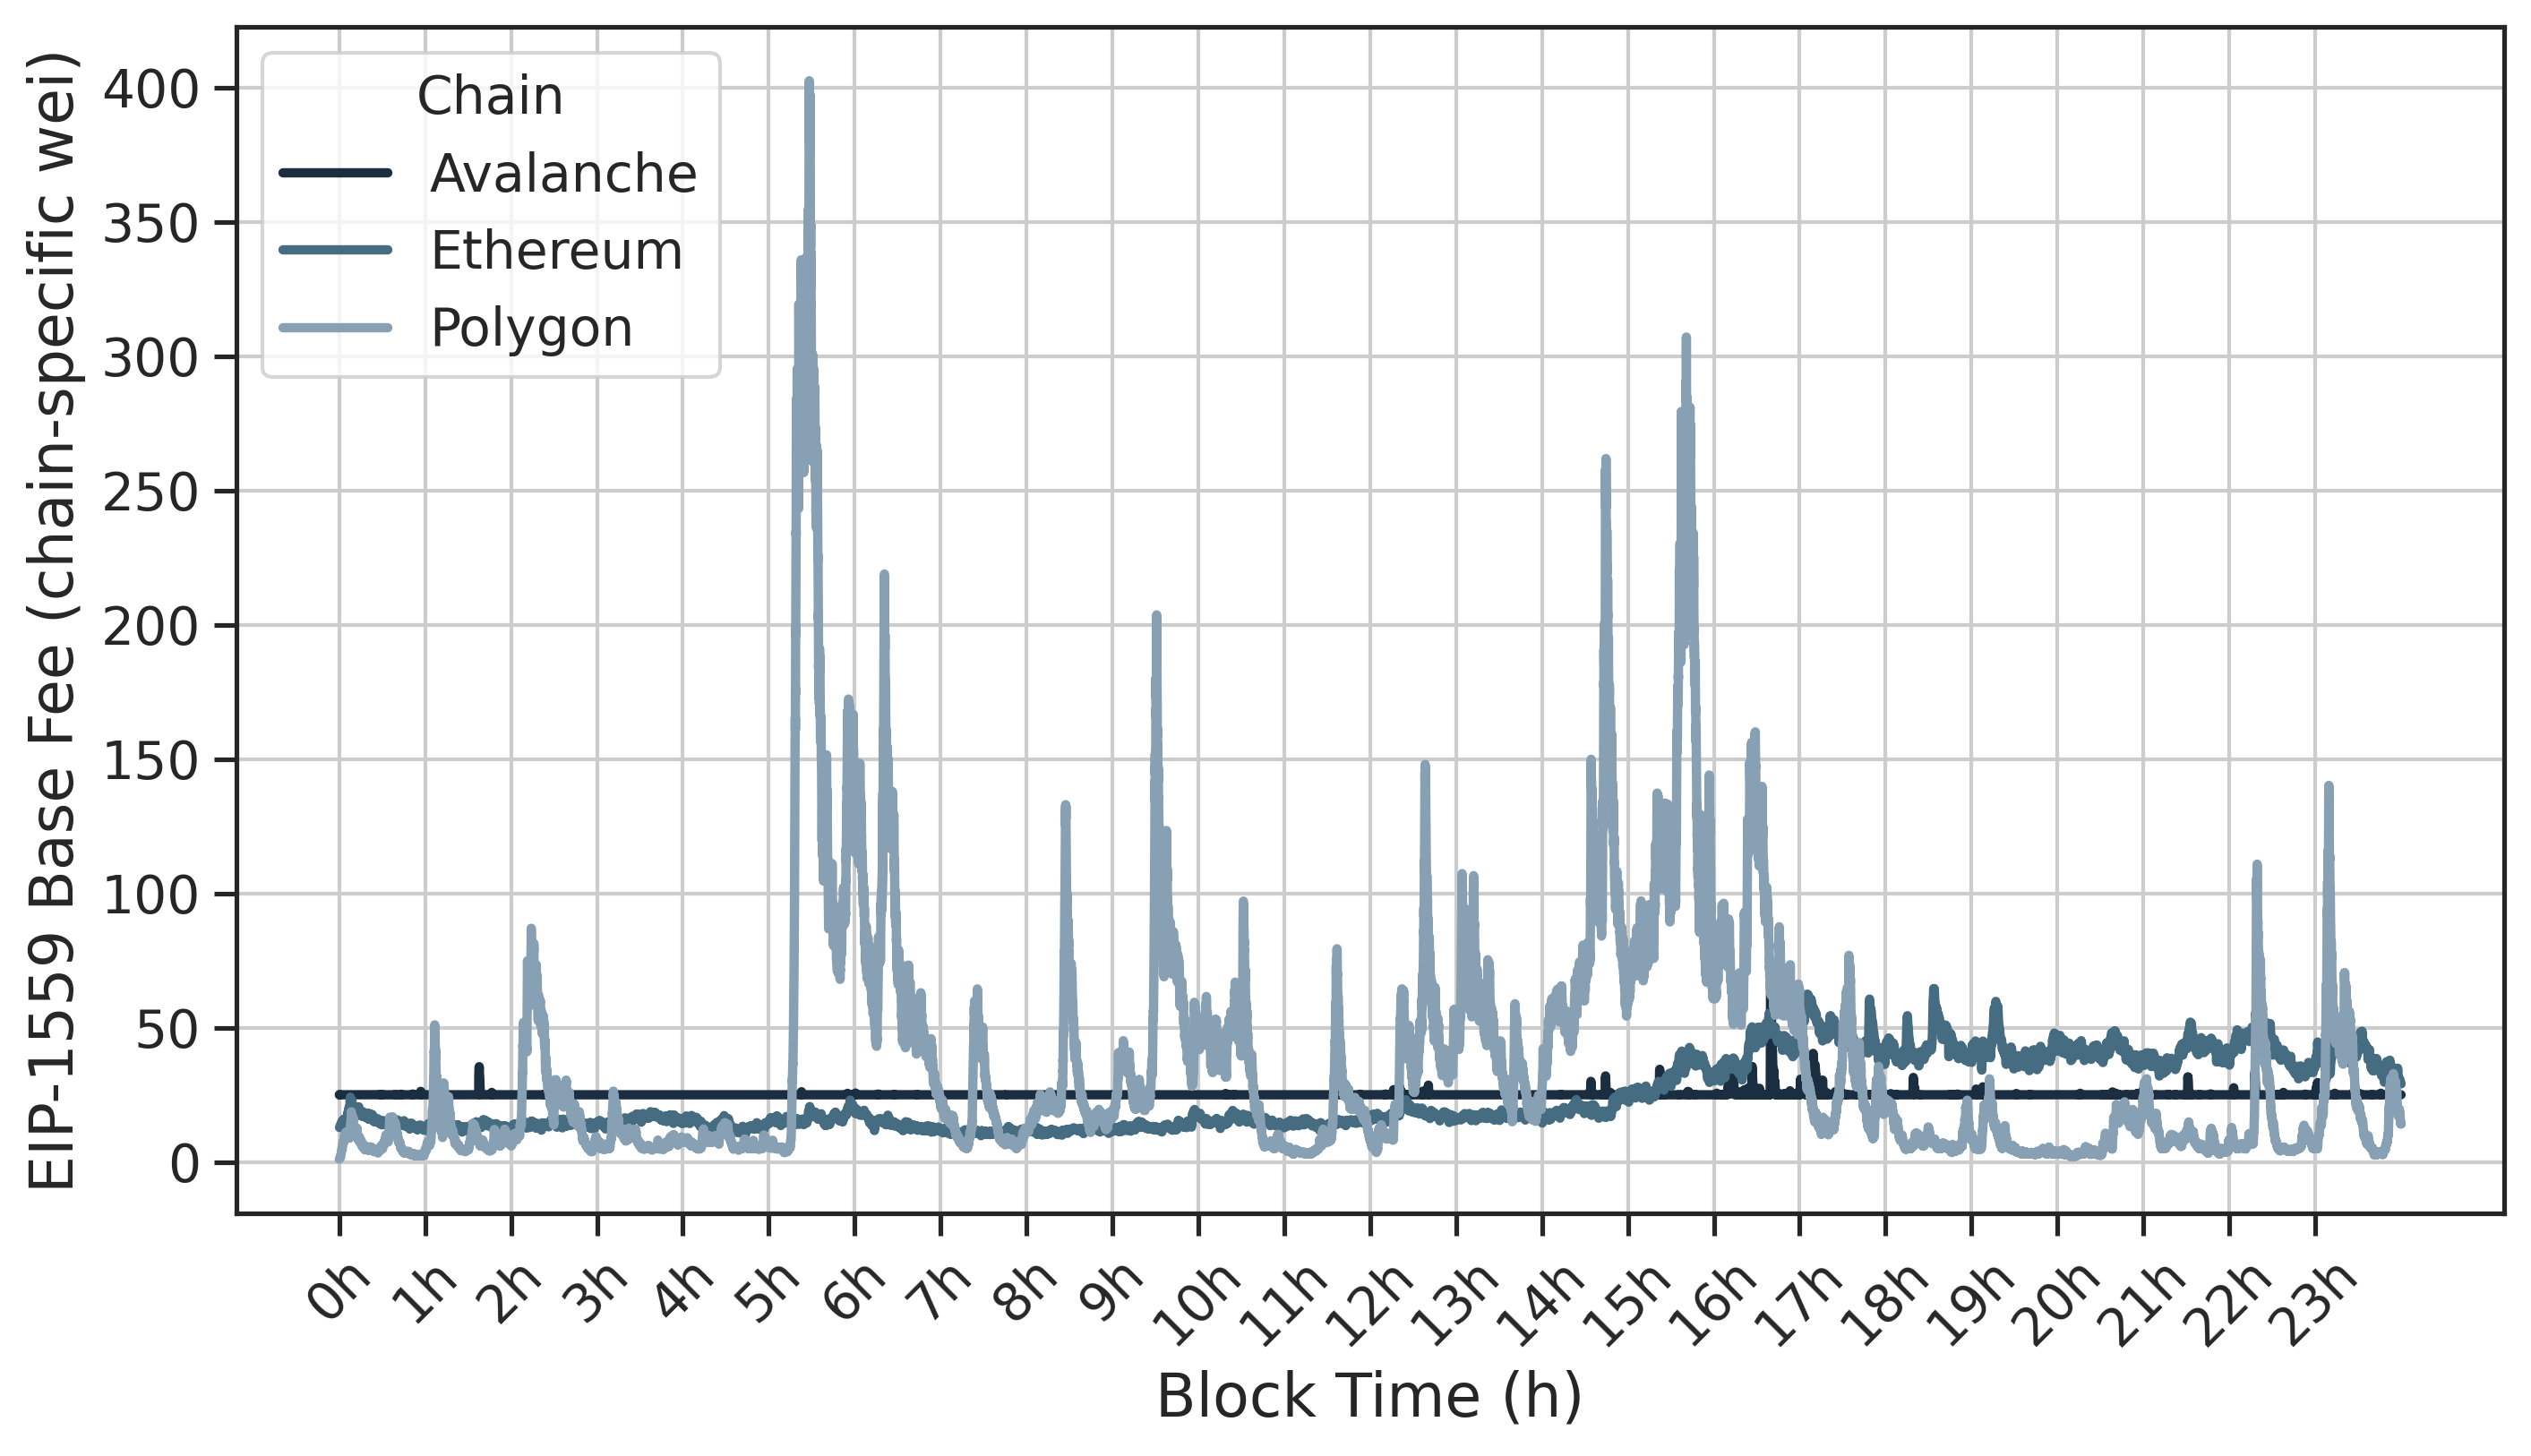

In [5]:
# Make a seasborn lineplot of the base_fee in each chain with the block_time on the x-axis
plt.figure(figsize=(10, 6))
hue_order = sorted(df_chains['chain'].unique())
sns.lineplot(data=df_chains, x="block_time", y="base_fee", hue="chain", hue_order=hue_order, palette=zonia_palette, linewidth=2.5)
plt.xticks(ticks=np.arange(0, df_chains['block_time'].max(), 3600), 
           labels=[f"{int(i/3600)}h" for i in np.arange(0, df_chains['block_time'].max(), 3600)],
           rotation=45)
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x/3600)}h"))
plt.xlabel("Block Time (h)")
plt.ylabel("EIP-1559 Base Fee (chain-specific wei)")
#plt.title("Base Fee Evolution")
plt.legend(title="Chain", loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig("base_fee_evolution.png", dpi=300)
plt.show()

/tmp/ipykernel_45614/902469579.py:4: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.lineplot(data=df_chains, x="block_time", y="base_fee_dollars", hue="chain", hue_order=hue_order, palette=zonia_palette, linewidth=2.5)


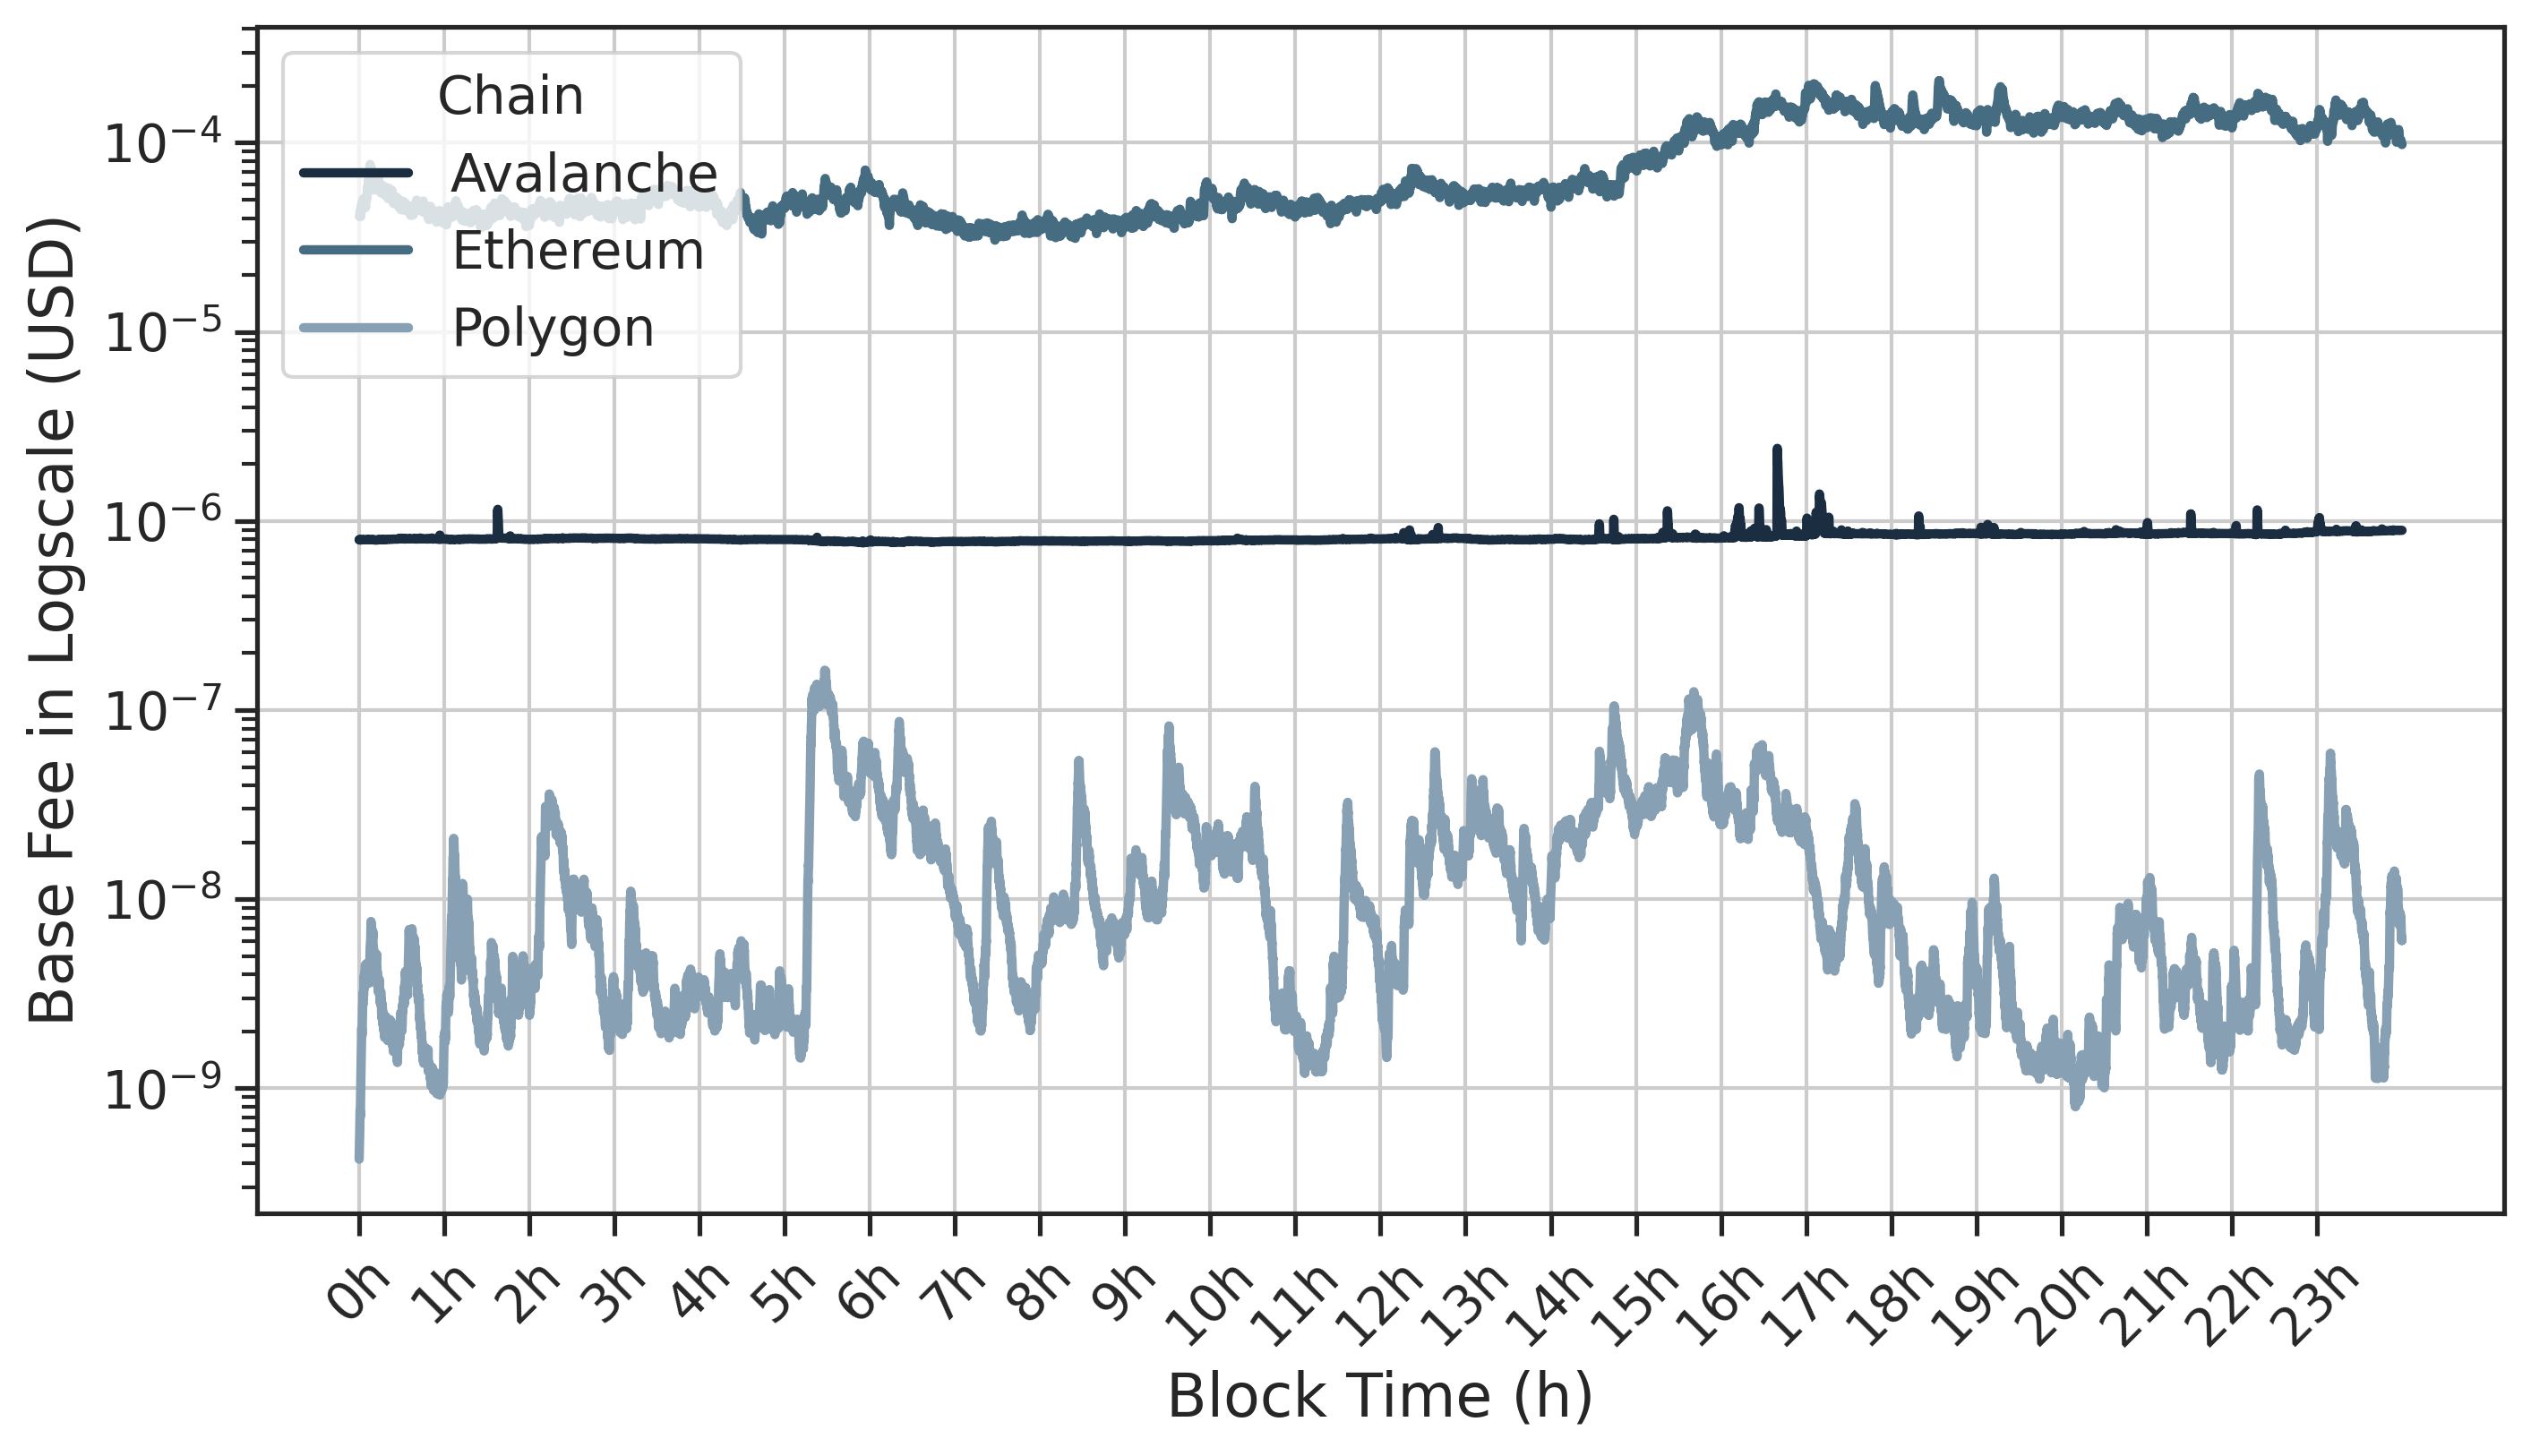

In [21]:
# Make a seasborn lineplot of the gas_price_dollars in each chain with the block_time on the x-axis
# Base fee is the cost in Dollars of one unit of Gas
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_chains, x="block_time", y="base_fee_dollars", hue="chain", hue_order=hue_order, palette=zonia_palette, linewidth=2.5)
plt.xticks(ticks=np.arange(0, df_chains['block_time'].max(), 3600), 
           labels=[f"{int(i/3600)}h" for i in np.arange(0, df_chains['block_time'].max(), 3600)],
           rotation=45)
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x/3600)}h"))
plt.xlabel("Block Time (h)")
plt.ylabel("Base Fee in Logscale (USD)")
plt.yscale('log')
#plt.title("Gas Price Evolution")
plt.legend(title="Chain", loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig("base_fee_usd_evolution.png", dpi=300)
plt.show()


/tmp/ipykernel_45614/2895950243.py:5: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.lineplot(data=df_chains, x="block_time", y="gas_price_dollars", hue="chain", hue_order=hue_order, palette=zonia_palette, linewidth=2.5)


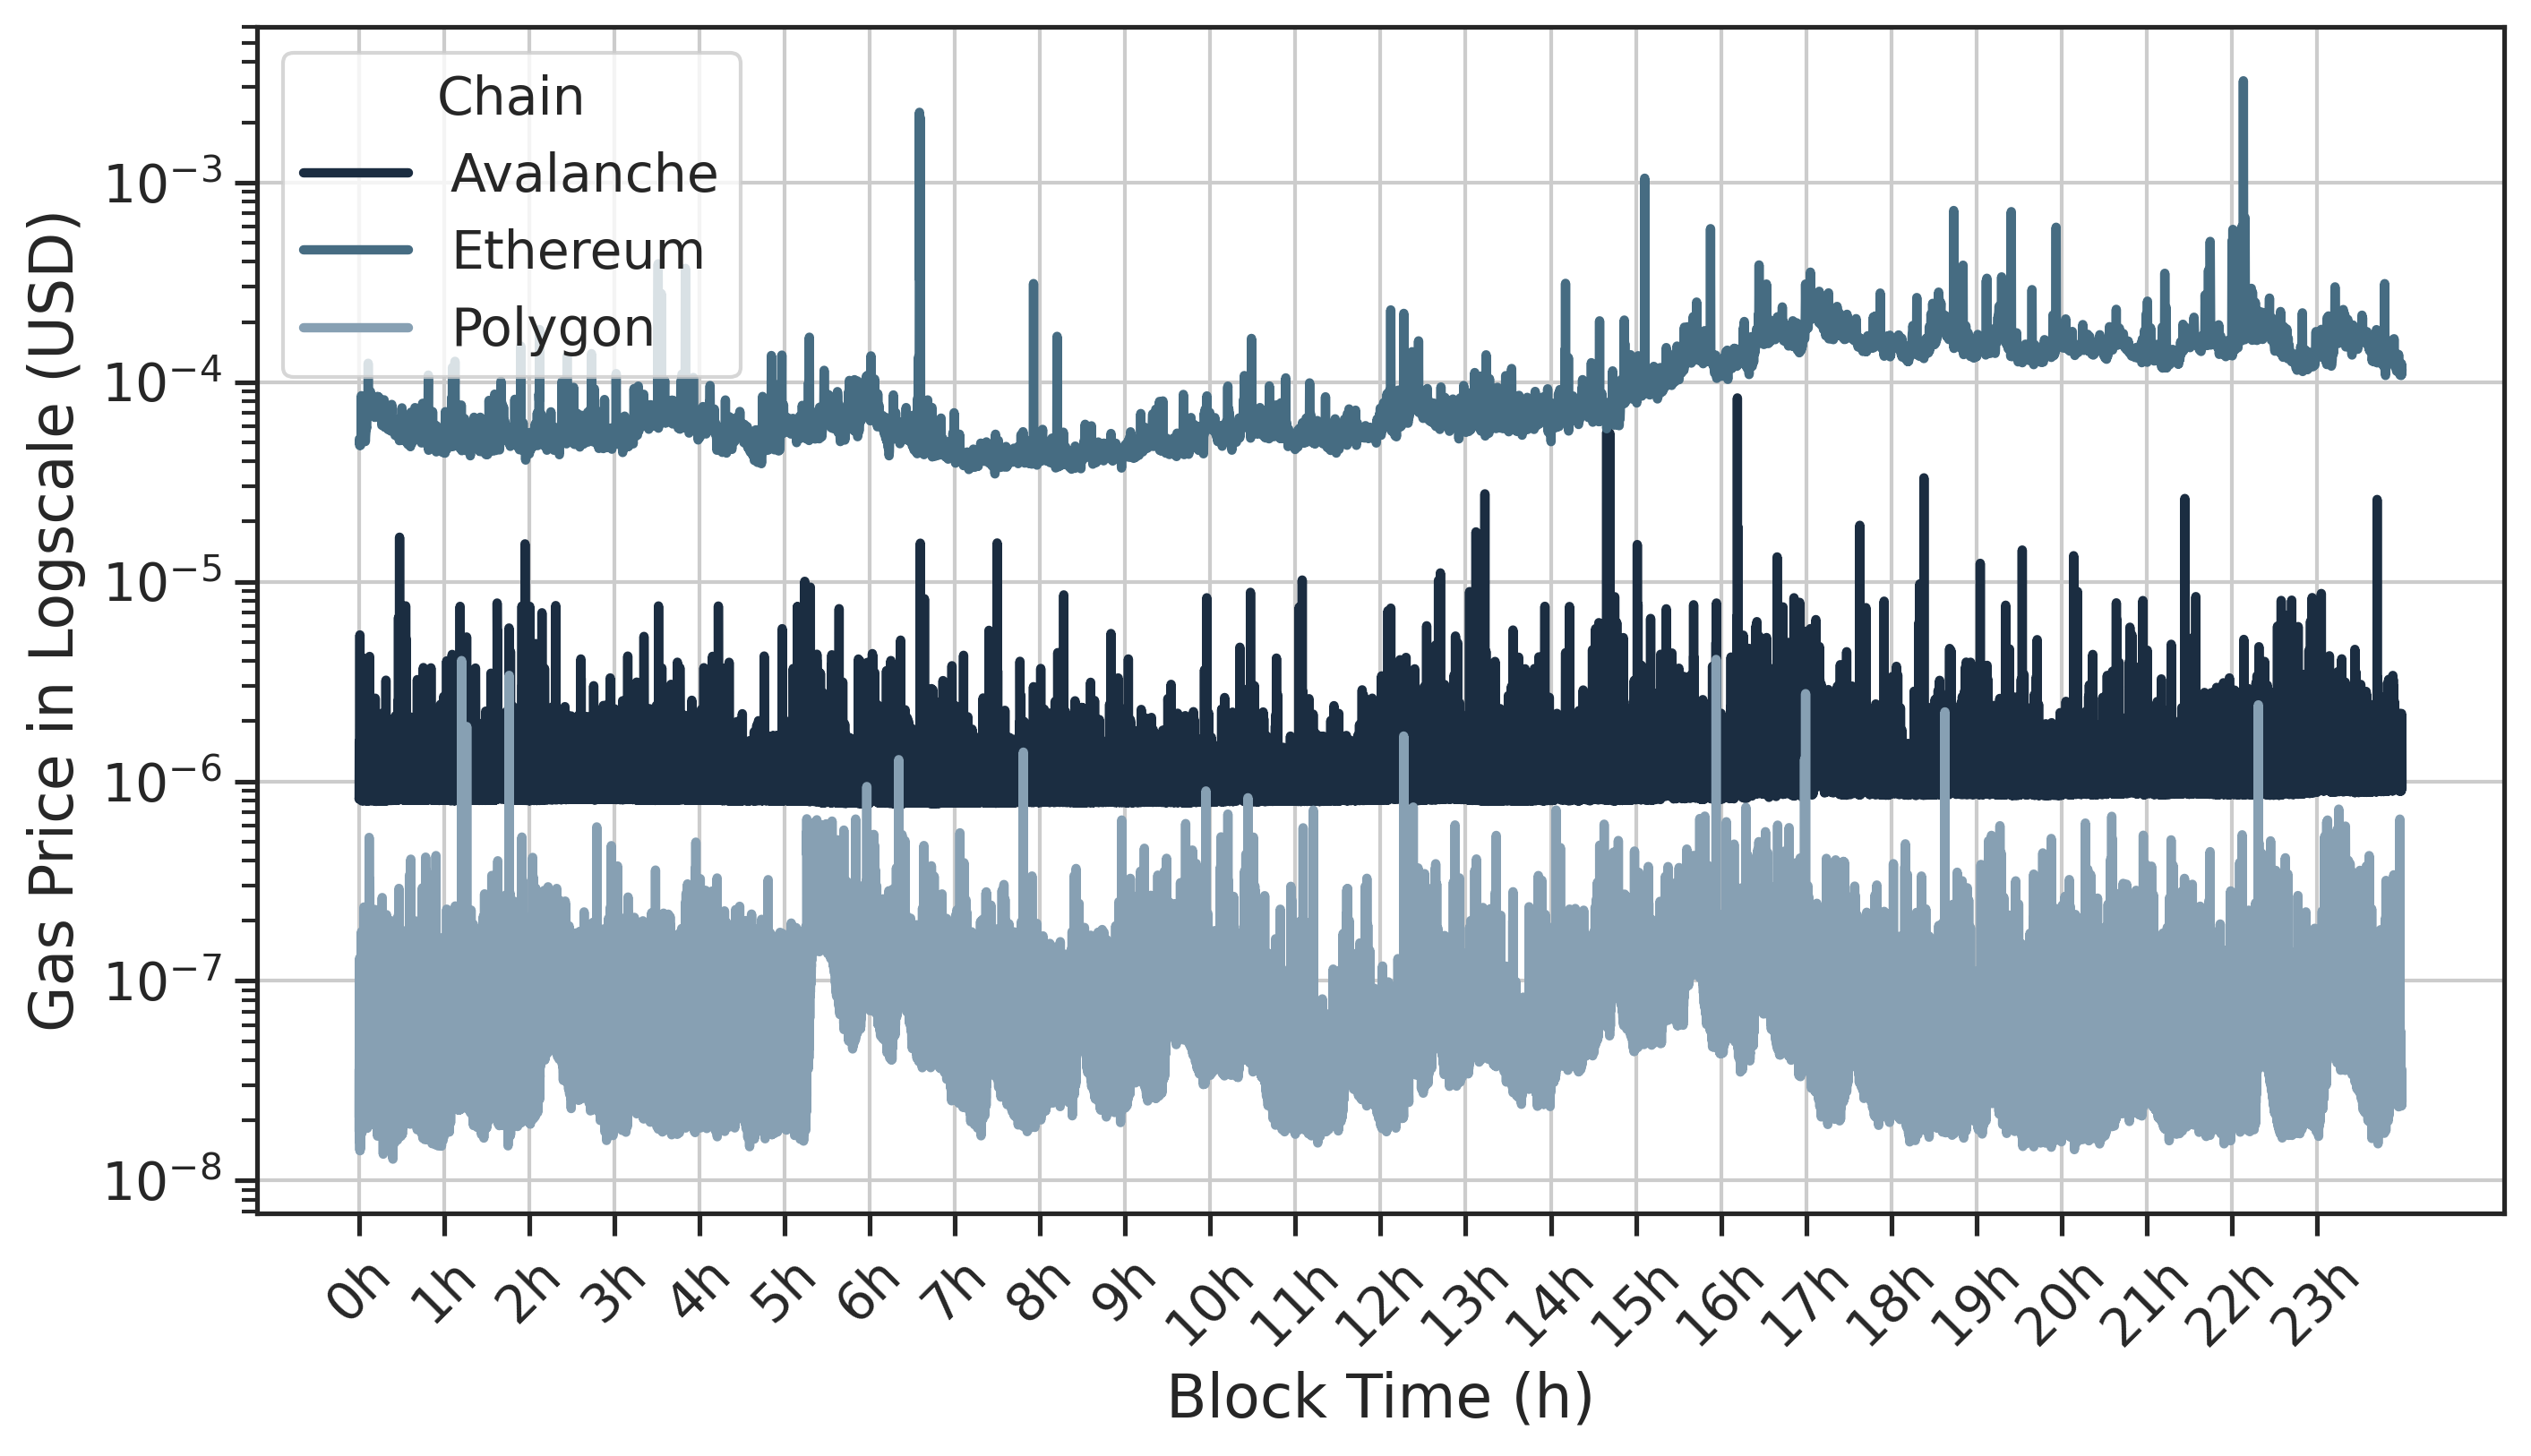

In [22]:
# Make a seaborn lineplot of the base_fee in each chain with the block_time on the x-axis
plt.figure(figsize=(10, 6))
hue_order = sorted(df_chains['chain'].unique())
#hue_order = [hue_order[2], hue_order[0], hue_order[1]]  # Reorder for better visibility
sns.lineplot(data=df_chains, x="block_time", y="gas_price_dollars", hue="chain", hue_order=hue_order, palette=zonia_palette, linewidth=2.5)
plt.xticks(ticks=np.arange(0, df_chains['block_time'].max(), 3600), 
           labels=[f"{int(i/3600)}h" for i in np.arange(0, df_chains['block_time'].max(), 3600)],
           rotation=45)
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x/3600)}h"))
plt.xlabel("Block Time (h)")
plt.ylabel("Gas Price in Logscale (USD)")
plt.yscale('log')
plt.legend(title="Chain", loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig("gas_price_evolution.png", dpi=300)
plt.show()

/tmp/ipykernel_45614/2204912279.py:4: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.lineplot(data=df_chains, x="block_time", y="waiting_time", hue="chain", hue_order=hue_order, palette=zonia_palette, linewidth=2.5)


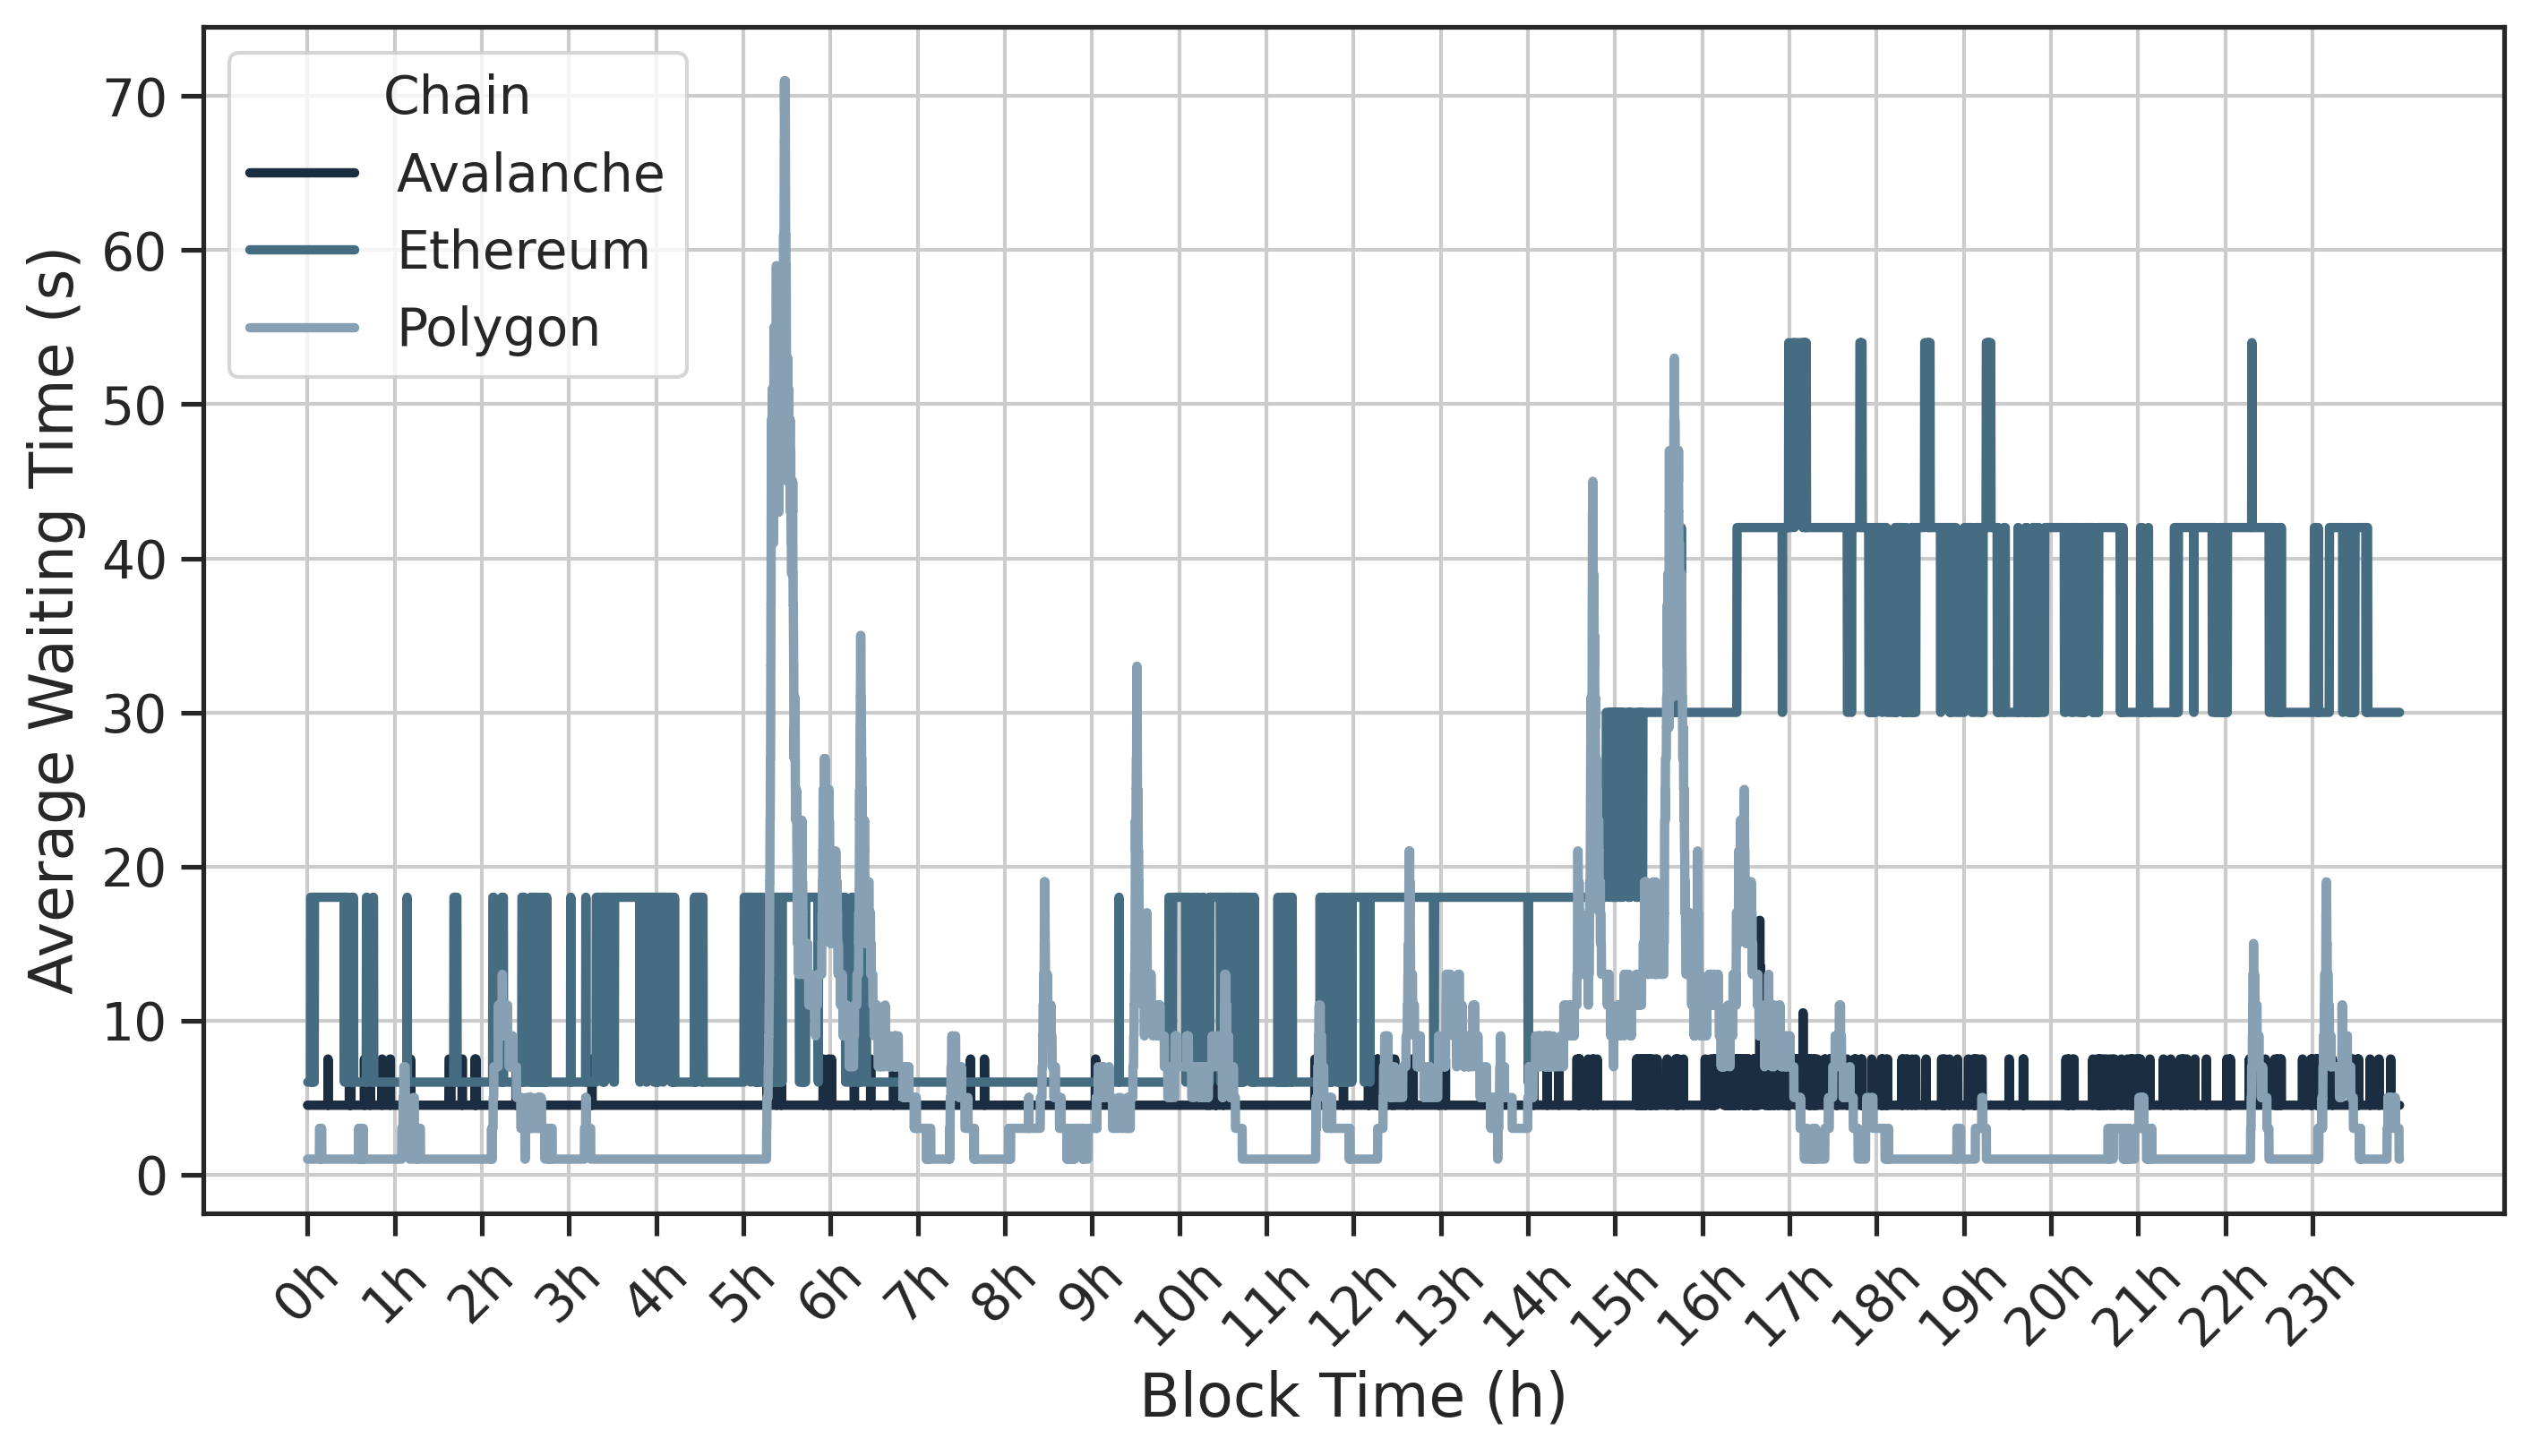

In [20]:
# Make a seasborn lineplot of the base_fee in each chain with the block_time on the x-axis
plt.figure(figsize=(10, 6))
hue_order = sorted(df_chains['chain'].unique())
sns.lineplot(data=df_chains, x="block_time", y="waiting_time", hue="chain", hue_order=hue_order, palette=zonia_palette, linewidth=2.5)
plt.xticks(ticks=np.arange(0, df_chains['block_time'].max(), 3600), 
           labels=[f"{int(i/3600)}h" for i in np.arange(0, df_chains['block_time'].max(), 3600)],
           rotation=45)
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x/3600)}h"))
plt.xlabel("Block Time (h)")
plt.ylabel("Average Waiting Time (s)")
#plt.title("Average Waiting Time Evolution")
plt.legend(title="Chain", loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig("waiting_time_evolution.png", dpi=300)
plt.show()

In [9]:
CHAIN_CONF = [
    "ZONIA-MC",
    "ZONIA-Ethereum",
    "ZONIA-Avalanche",
    "ZONIA-Polygon",
]

parent_folder  = "results-distributed"
all_files = glob.glob(os.path.join(parent_folder, "*.csv"))
HEADERS = ["time", "sources", "malign", "ban_sources", "ban_malign", "consensus", "rep_benign", "rep_malign", "event_type", "actual_delay", "actual_cost", "relay_chain", "actual_objective", "optimal_objective"]
print("Found {} results".format(len(all_files)))

print("Import results...")
_li = []
for filename in tqdm(all_files):
    _df = pd.read_csv(filename, index_col=None, header=None, names=HEADERS)
    _params = os.path.splitext(filename)[0].split("_")
    _df['rep_min'] = float(_params[1])
    _df['ratio_malign'] = float(_params[2])
    _df['cost_time_param'] = float(_params[3]) 
    _df['fav_chain'] = float(_params[4])
    _df['repetition'] = float(_params[5])
    _df['Algorithm'] = float(_params[6])
    _df['Arrival'] = _params[7]
    _df['Ratio Malicious Oracles'] = float(_params[8])
    _df['truth'] = int(_params[9])
    # Local Processing
    
    if float(_params[5]) < 20: # Only process the fourth repetition
        _li.append(_df)
df = pd.concat(_li, axis=0, ignore_index=True)
df.drop(columns=["sources", "rep_min", "truth"], inplace=True)
#df = df[df['Ratio Malicious Oracles'] <= 0.0]
print("We ended up with {} rows".format(len(df)))

Found 2500 results
Import results...


100%|██████████| 2500/2500 [00:05<00:00, 483.96it/s]


We ended up with 900312 rows


In [10]:
# Calculate precision and recall
print("Calculate precision and recall for df")
df['Recall'] = df.apply(lambda row: (row['ban_malign'] / row['malign'] if row['malign'] else 0), axis=1)
print("Recall done")
df['Precision'] = df.apply(lambda row: (row['ban_malign'] / row['ban_sources'] if row['ban_sources'] else 0), axis=1)
print("Precision done")
# Calculate Consensus Accuracy
GROUND_TRUTH = 25
TOLERANCE = 3
df['Consensus Accuracy'] = df.apply(lambda row: (1 if abs(row['consensus'] - GROUND_TRUTH) < TOLERANCE else 0), axis=1)
print("Consensus Accuracy done")
# Calculate the objective percentage
df['Objective Percentage'] = df.apply(lambda row: (row['actual_objective'] / row['optimal_objective'] if row['optimal_objective'] else 0.0), axis=1)
# Adjust the cost to USD
df['actual_cost'] = df['actual_cost'] / 1e9  # Adjust the cost to USD

Calculate precision and recall for df
Recall done
Precision done
Consensus Accuracy done


In [11]:
df.drop(columns=["event_type"], inplace=True)
#df = df[df['actual_cost'] > 0.0]
df

,time,malign,ban_sources,ban_malign,consensus,rep_benign,rep_malign,actual_delay,actual_cost,relay_chain,...,cost_time_param,fav_chain,repetition,Algorithm,Arrival,Ratio Malicious Oracles,Recall,Precision,Consensus Accuracy,Objective Percentage
0,39.50,20,0,0,25.102372,0.000000,0.000000,2.50,1.978001e-09,polygon,...,1.0,0.0,14.0,2.0,uniform,0.0,0.0,0.0,1,1.0
1,76.28,20,0,0,25.014202,0.000000,0.000000,3.72,1.949971e-09,polygon,...,1.0,0.0,14.0,2.0,uniform,0.0,0.0,0.0,1,1.0
2,84.51,20,0,0,24.977213,0.000000,0.000000,5.49,1.803426e-09,polygon,...,1.0,0.0,14.0,2.0,uniform,0.0,0.0,0.0,1,1.0
3,85.39,20,0,0,25.000376,0.000000,0.000000,4.61,1.803426e-09,polygon,...,1.0,0.0,14.0,2.0,uniform,0.0,0.0,0.0,1,1.0
4,125.37,20,0,0,25.006465,0.000000,0.000000,2.63,1.880362e-09,polygon,...,1.0,0.0,14.0,2.0,uniform,0.0,0.0,0.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900307,6791.31,30,27,27,24.759210,0.573784,-0.437166,-36528.00,2.289651e-09,polygon,...,1.0,-1.0,2.0,2.0,uniform,0.0,0.9,1.0,1,1.0
900308,6795.17,30,27,27,25.069623,0.573572,-0.437166,-36528.00,2.222619e-09,polygon,...,1.0,-1.0,2.0,2.0,uniform,0.0,0.9,1.0,1,1.0
900309,6820.43,30,27,27,24.940209,0.572097,-0.437166,-36528.00,2.320499e-09,polygon,...,1.0,-1.0,2.0,2.0,uniform,0.0,0.9,1.0,1,1.0
900310,6848.08,30,27,27,25.025950,0.568593,-0.437166,-36528.00,2.103332e-09,polygon,...,1.0,-1.0,2.0,2.0,uniform,0.0,0.9,1.0,1,1.0


/tmp/ipykernel_45614/2398777617.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df[df['fav_chain'] == 0.0], x="relay_chain", palette=zonia_palette, stat="percent", common_norm=False)


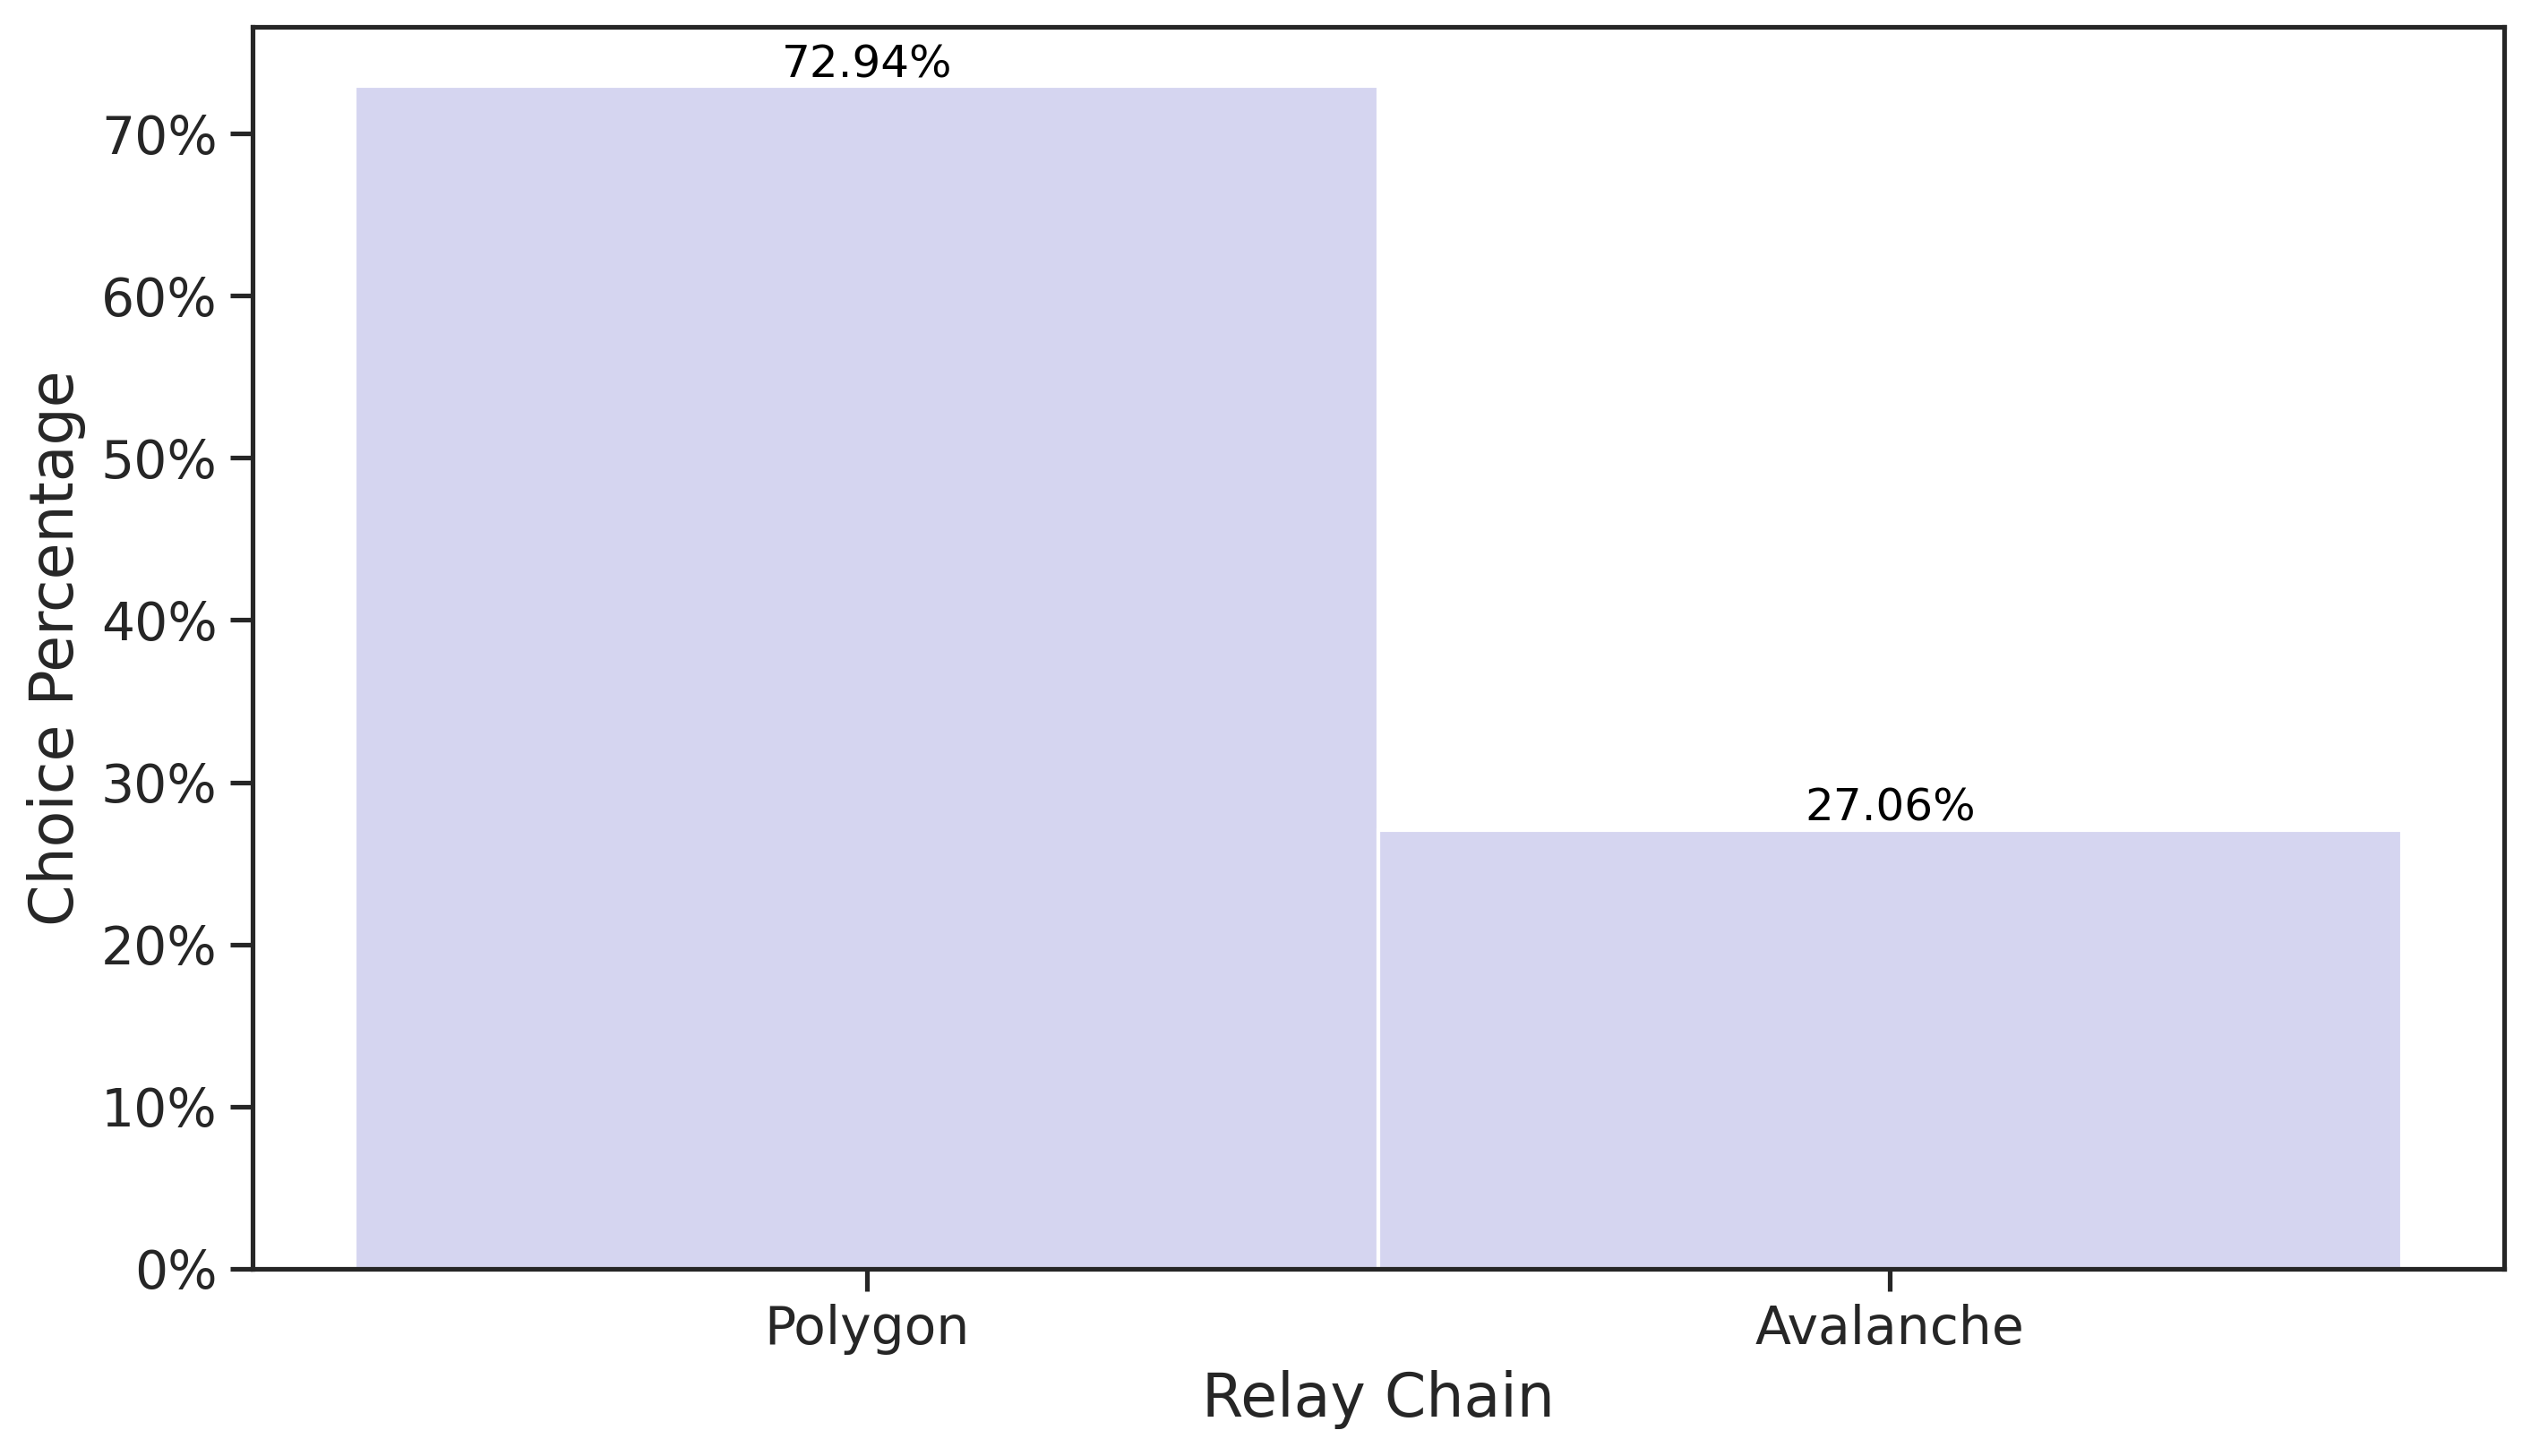

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df[df['fav_chain'] == 0.0], x="relay_chain", palette=zonia_palette, stat="percent", common_norm=False)
for p in plt.gca().patches:
    plt.gca().annotate(f'{round(p.get_height(), 2)}%', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', fontsize=12, color='black')
plt.xlabel("Relay Chain")
plt.ylabel("Choice Percentage")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
# Capitalize the xticks
plt.xticks(ticks=plt.gca().get_xticks(), labels=[label.get_text().capitalize() for label in plt.gca().get_xticklabels()])
#plt.title("Distribution of Relay Chain choice in ZONIA-MC over all configurations ")
plt.tight_layout()
plt.savefig("relay_chain_distribution.png", dpi=300)
plt.show()

In [13]:
import matplotlib.ticker as tkr
def numfmt(x, pos): # your custom formatter function: divide by 100.0
    s = '{}'.format(float(x) / 100.0)
    return s

def zonia_barplot(img_name, dataframe, chain_name="ZONIA-MC"): 
    print("Doing the bars...")
    df_bar = dataframe.groupby(['ratio_malign', 'Algorithm', 'Arrival'])['Consensus Accuracy'].agg(['sum','count']).reset_index()
    df_bar['Accuracy'] = df_bar.apply(lambda x: float(x['sum']) / float(x['count']) , axis=1)
    df_bar['ratio_malign'] = df_bar.apply(lambda x: float(x['ratio_malign'] * 100.0), axis=1)
    df_bar = df_bar.groupby(['ratio_malign', 'Algorithm', 'Arrival'])['Accuracy'].agg(['mean','std']).reset_index()

    print ("Doing " + img_name)
    xvals = df_bar['ratio_malign'].unique()
    algos = df_bar['Algorithm'].unique()
    arrs = np.flip(df_bar['Arrival'].unique())

    width = 1.5

    colors = ["#1B2D41", "#466C82", "#87A0B3",  "#D1E1F2"]
    hatches = ['','//']

    fig, ax  = plt.subplots()

    plt.xticks(xvals)
    xvals = xvals - (len(algos) * len(arrs) * width / 2) - (width/2)
    plt.xlabel('RMI', fontsize=16)
    plt.ylabel('Accuracy of ' + chain_name, fontsize=16)
    plt.rcParams['mathtext.default'] = 'regular'
    for i, algo in enumerate(algos):
        for j, arr in enumerate(arrs):
            xvals = xvals + width
            xlist = xvals.tolist()
            yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
            yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
            plt.bar(xvals, yvals, color = colors[i], width = width, label = str(algo)+str(arr), hatch=hatches[j], yerr=yerrs)
            for h in range(len((yvals))):
                ax.text(xlist[h] - width/2 + 0.05, yvals[h] + 0.01, str('{0:.2f}'.format(yvals[h])), rotation=90, fontsize=6, color='black', fontweight='bold')
            # for pos, y, err in zip(xvals, yvals, yerrs):
            #     ax.errorbar(pos, y, err, lw = 2,
            #                 capsize = 4, capthick = 2,
            #                 color = "red")
    plt.legend(loc='upper center', bbox_to_anchor=(0.48, 1.20), ncol=3, labels=['Med (uniform)', 'Med (bursty)', 'Med-R (uniform)', 'Med-R (bursty)', 'Med-RB (uniform)', 'Med-RB (bursty)'])
    plt.ylim([0,1.1])
    plt.gca().xaxis.set_major_formatter(tkr.FuncFormatter(numfmt))
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")

Doing the bars...
Doing ideal_accuracy_tail.png
ideal_accuracy_tail.png Done!
Doing the bars...
Doing zoniamc_accuracy_tail.png
zoniamc_accuracy_tail.png Done!
Doing the bars...
Doing ethereum_accuracy_tail.png
ethereum_accuracy_tail.png Done!
Doing the bars...
Doing avalanche_accuracy_tail.png
avalanche_accuracy_tail.png Done!
Doing the bars...
Doing polygon_accuracy_tail.png
polygon_accuracy_tail.png Done!


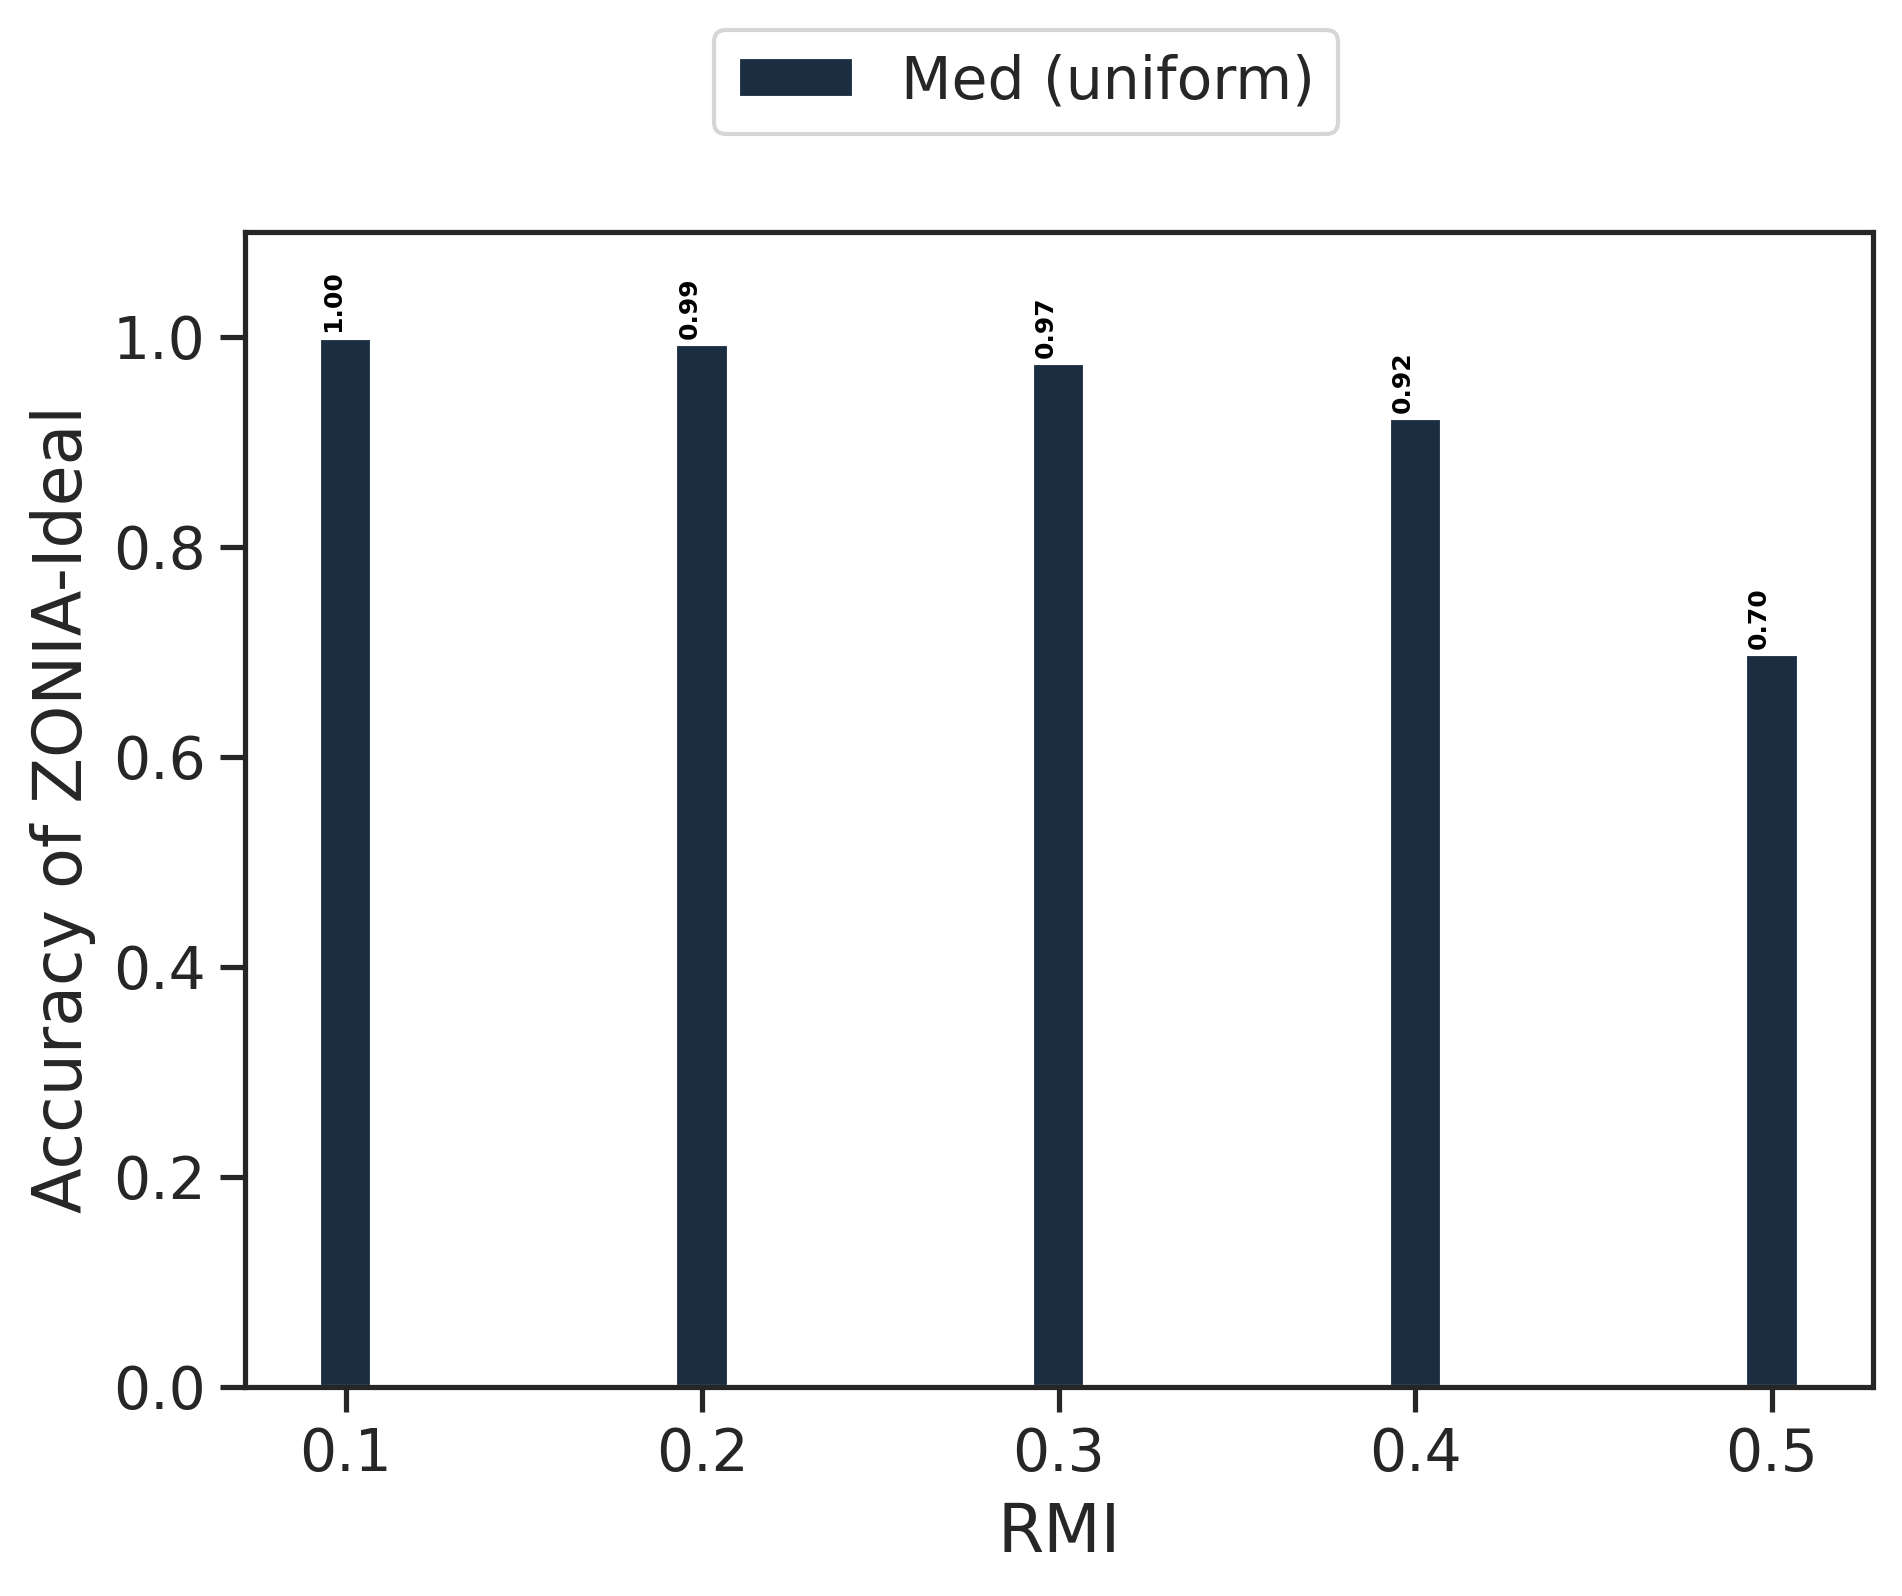

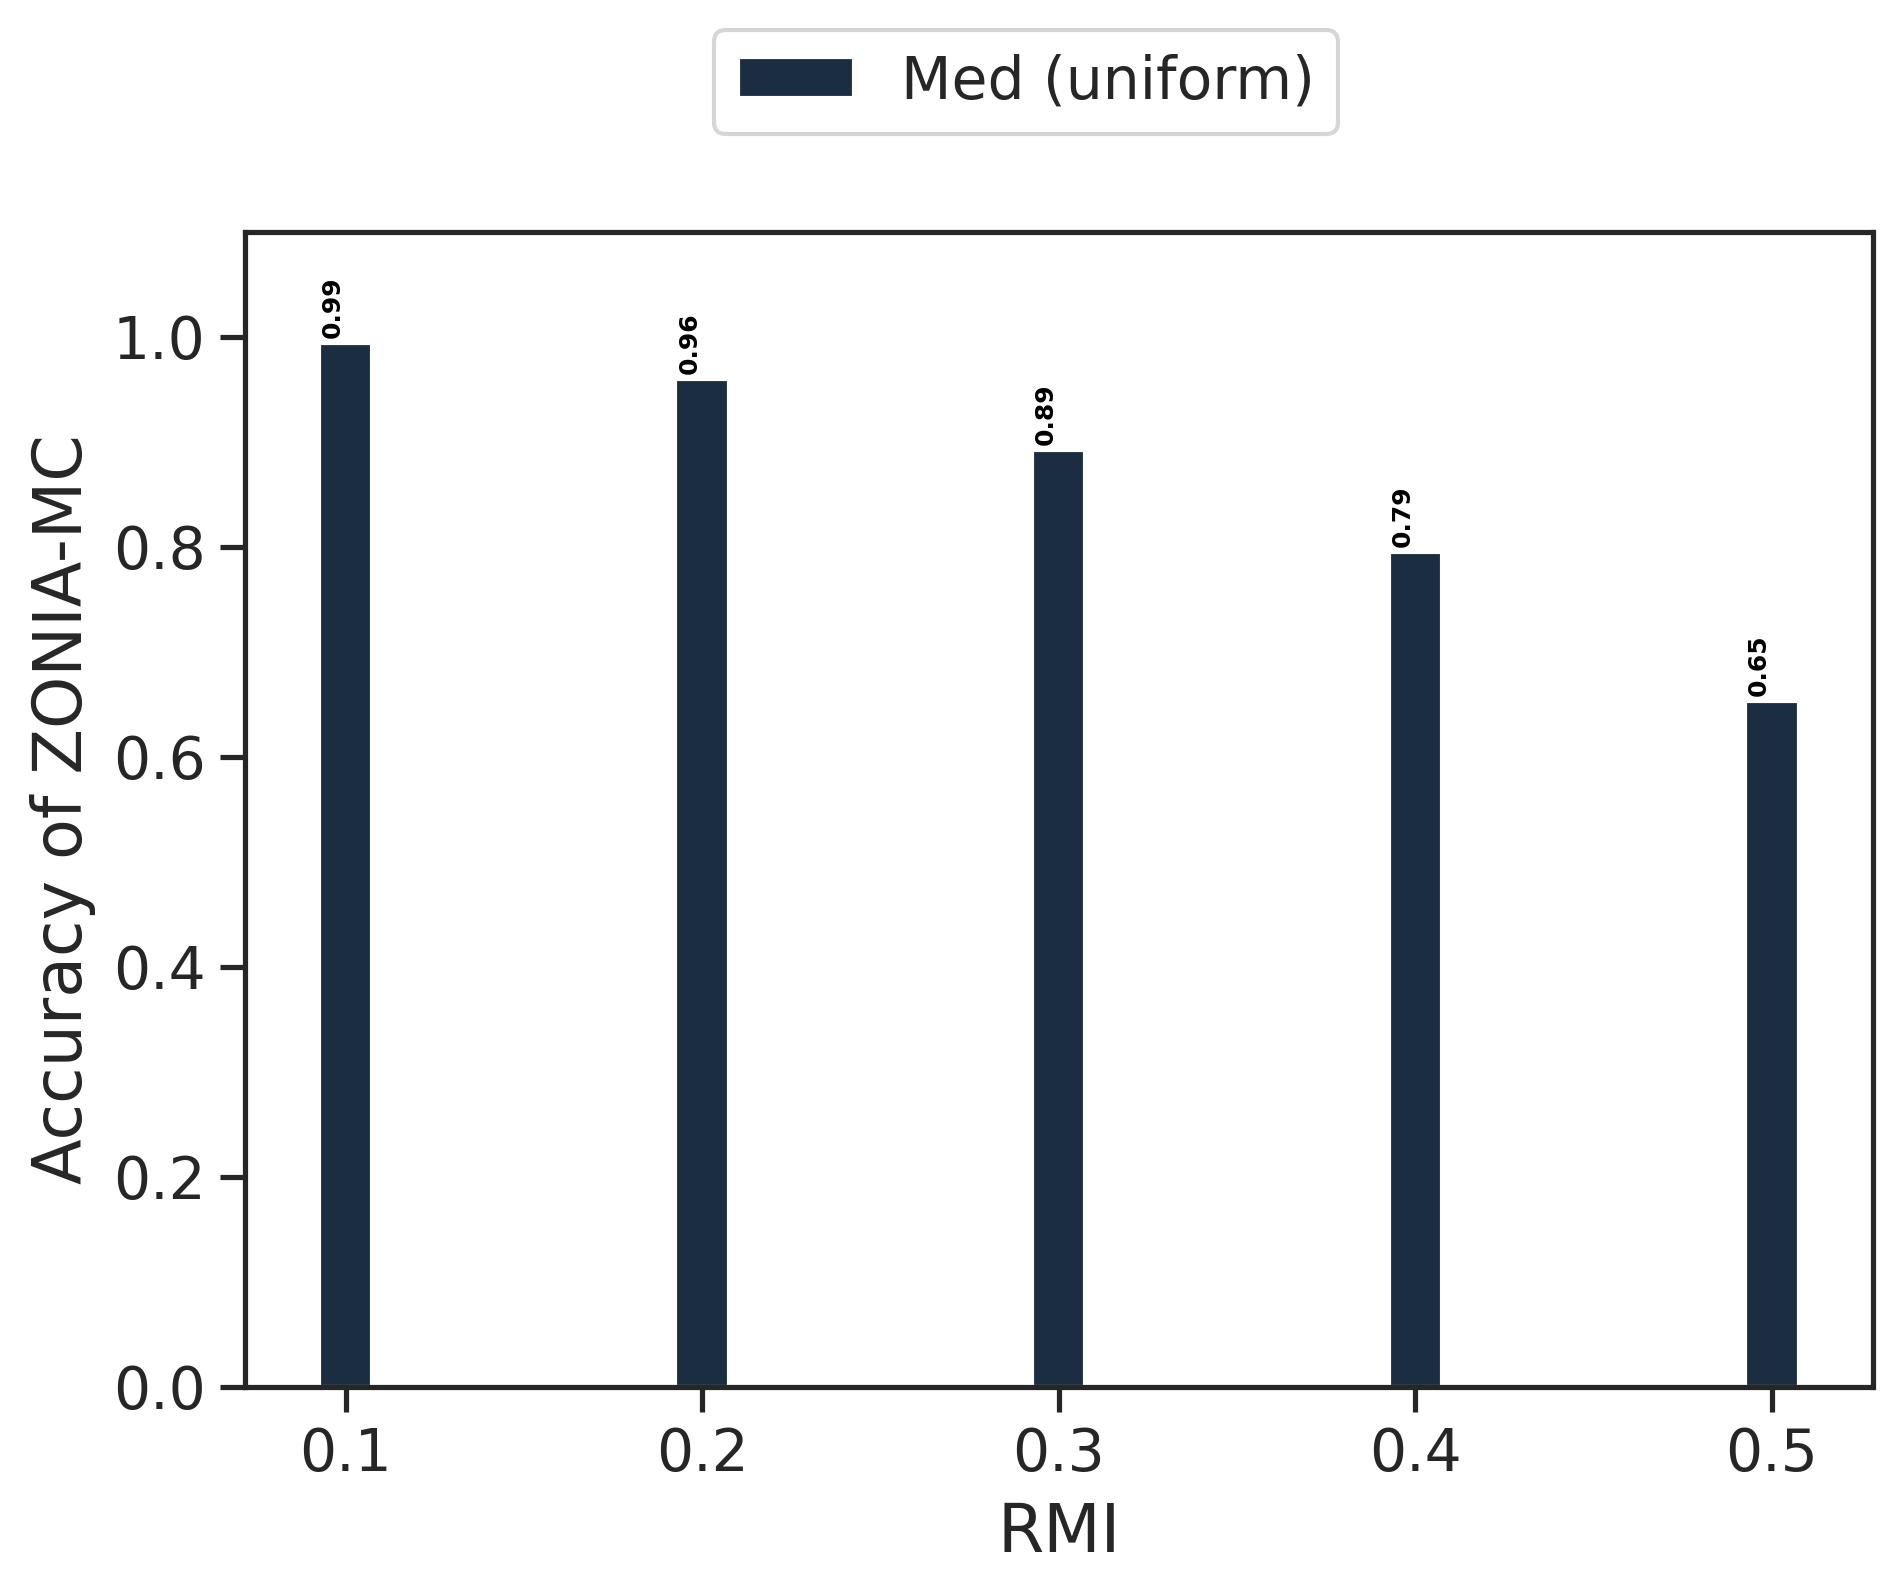

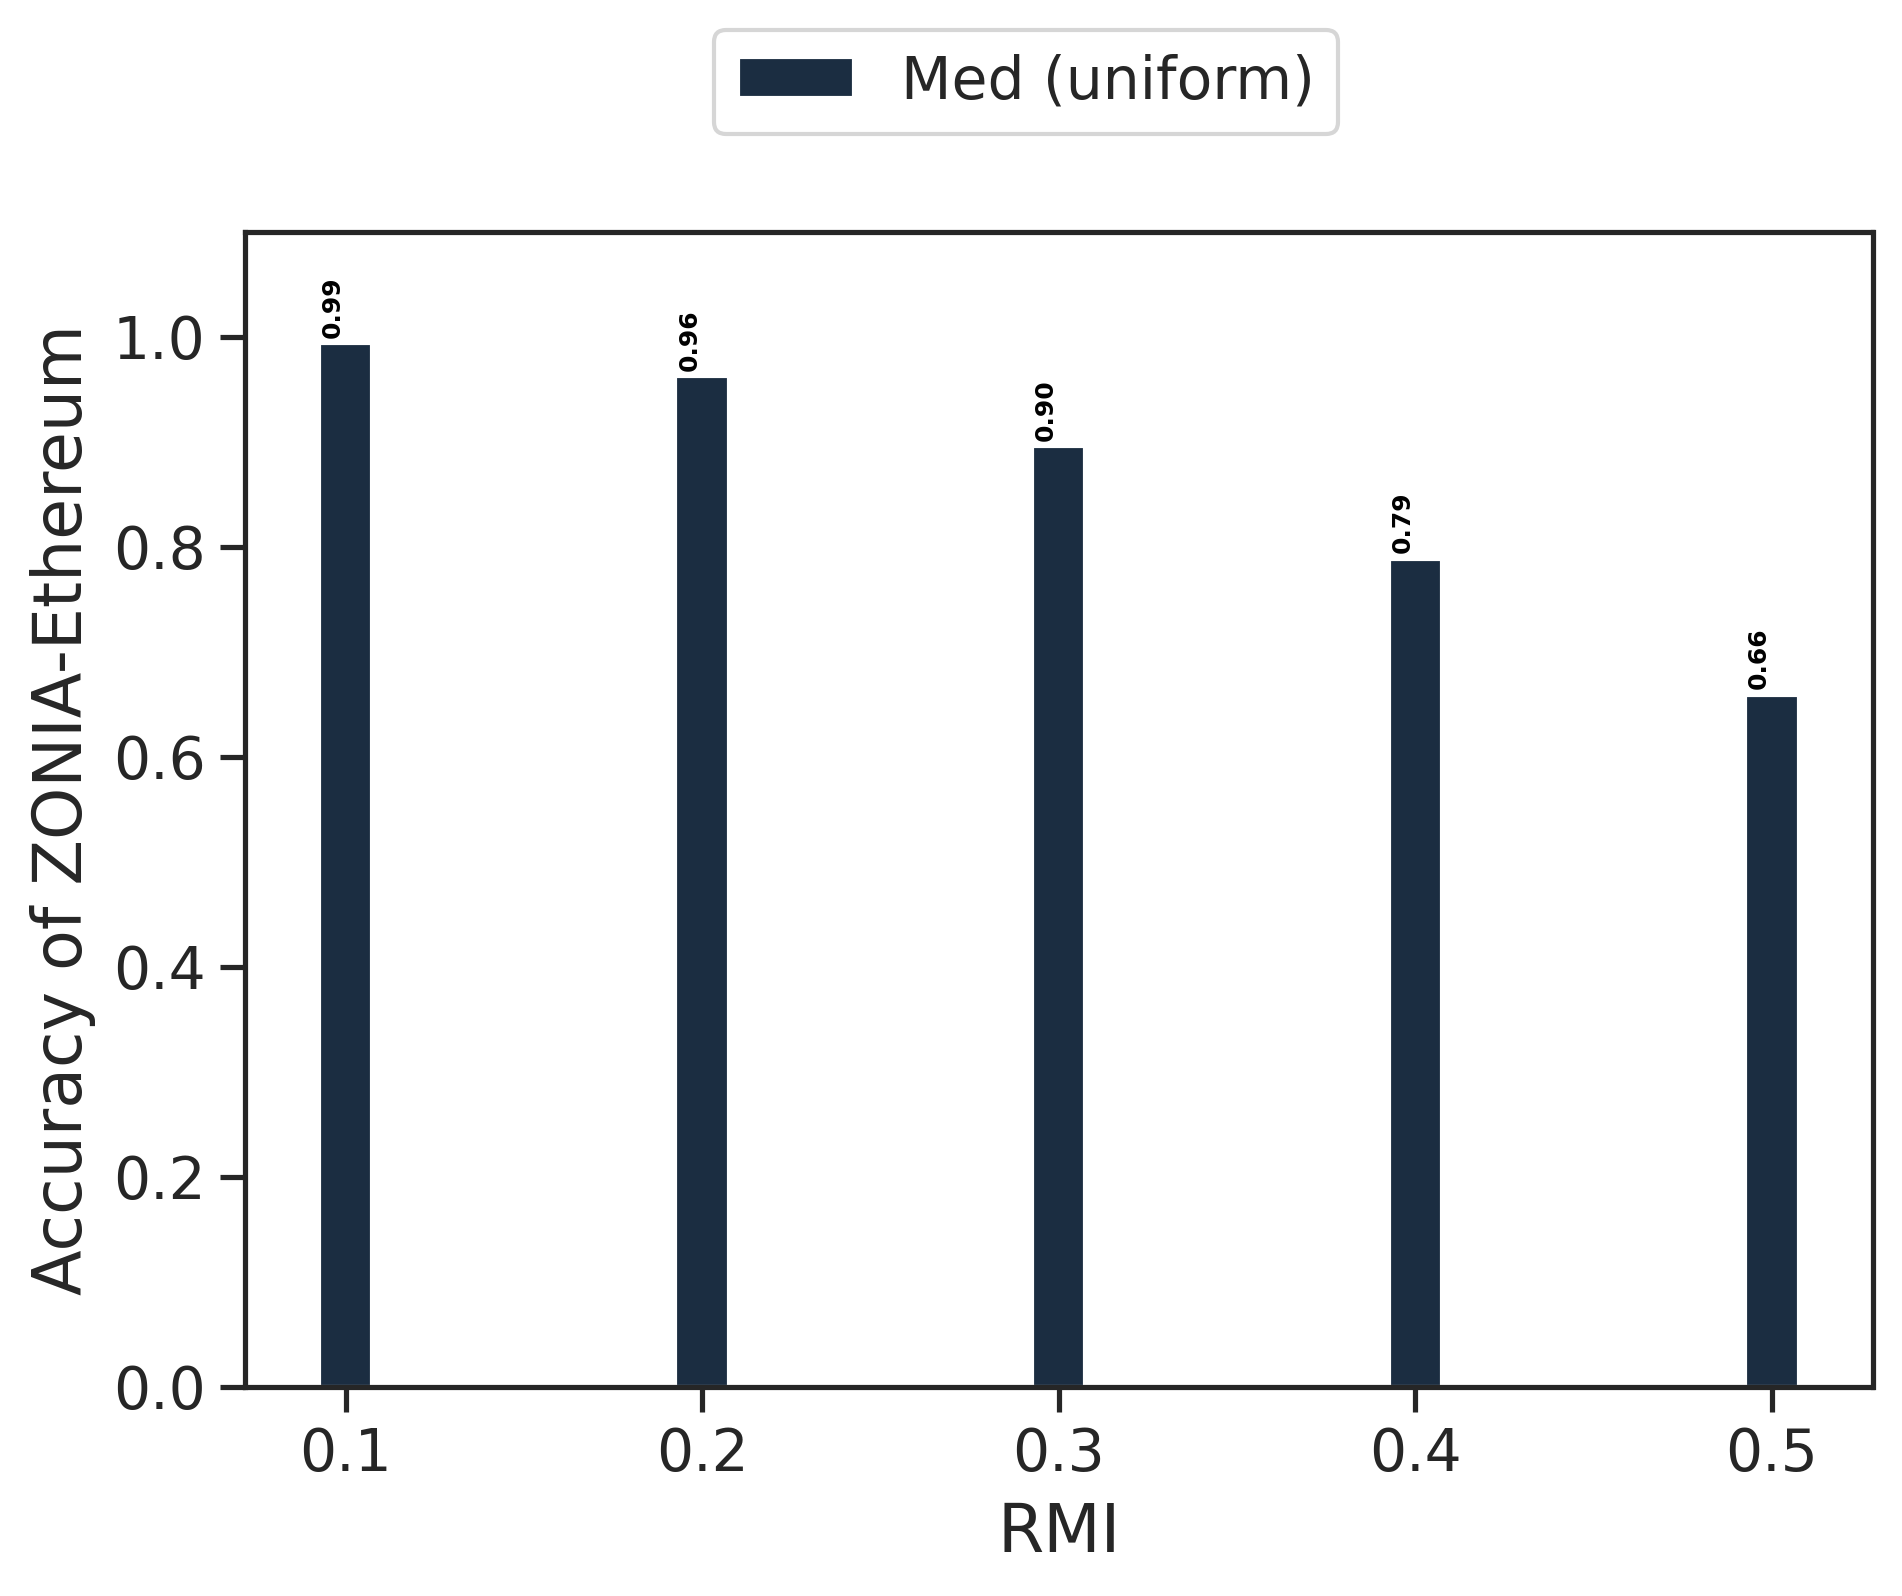

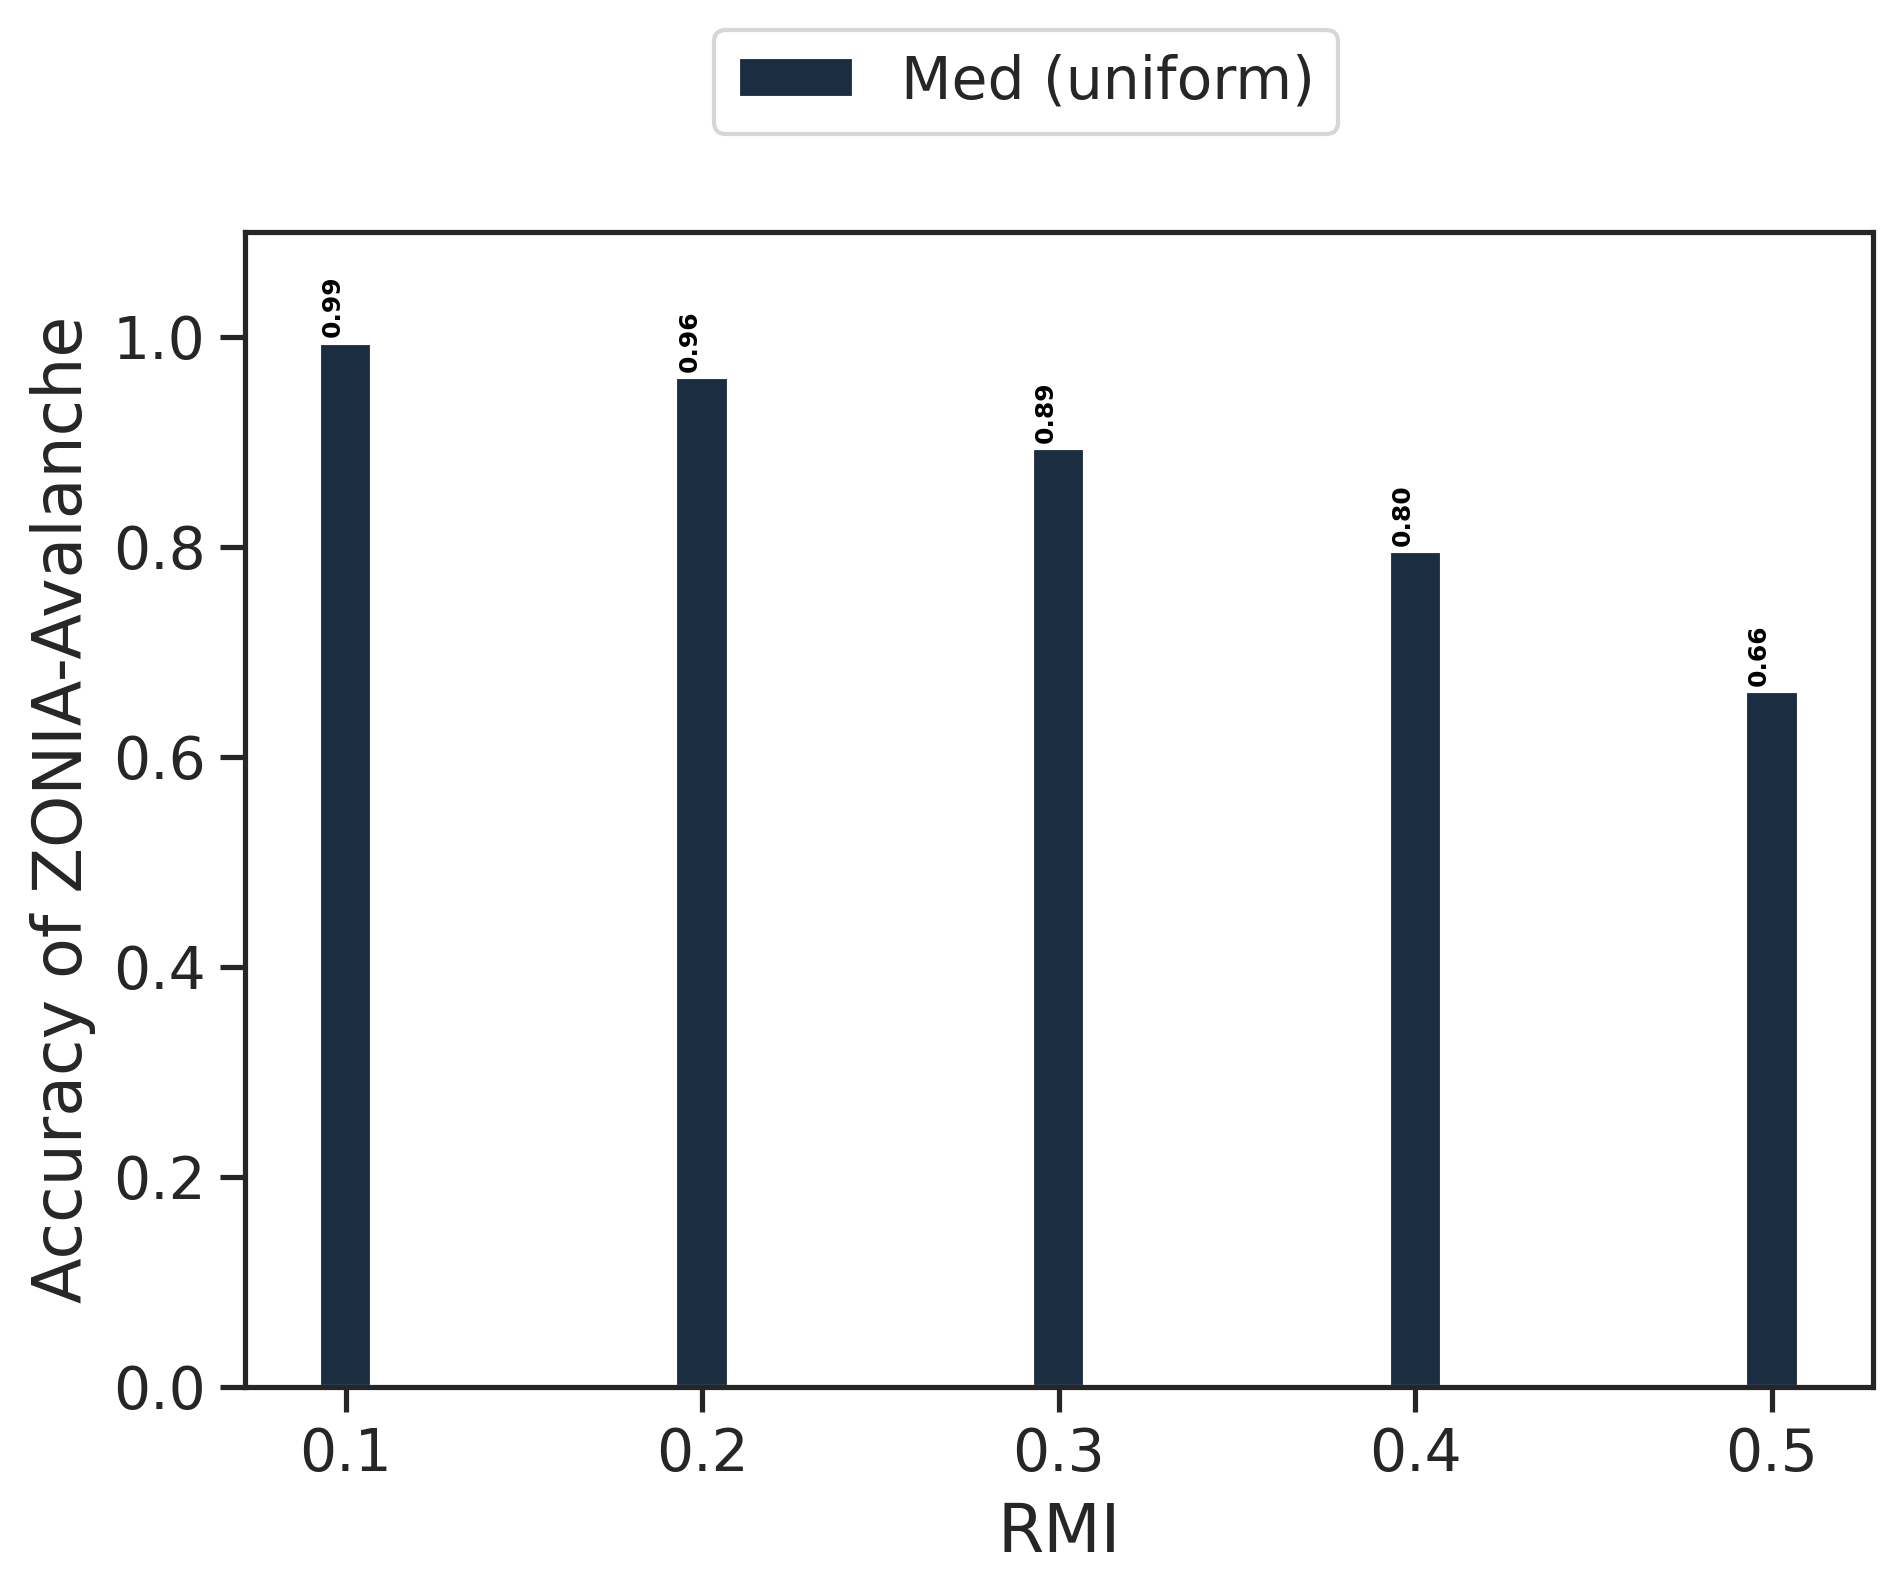

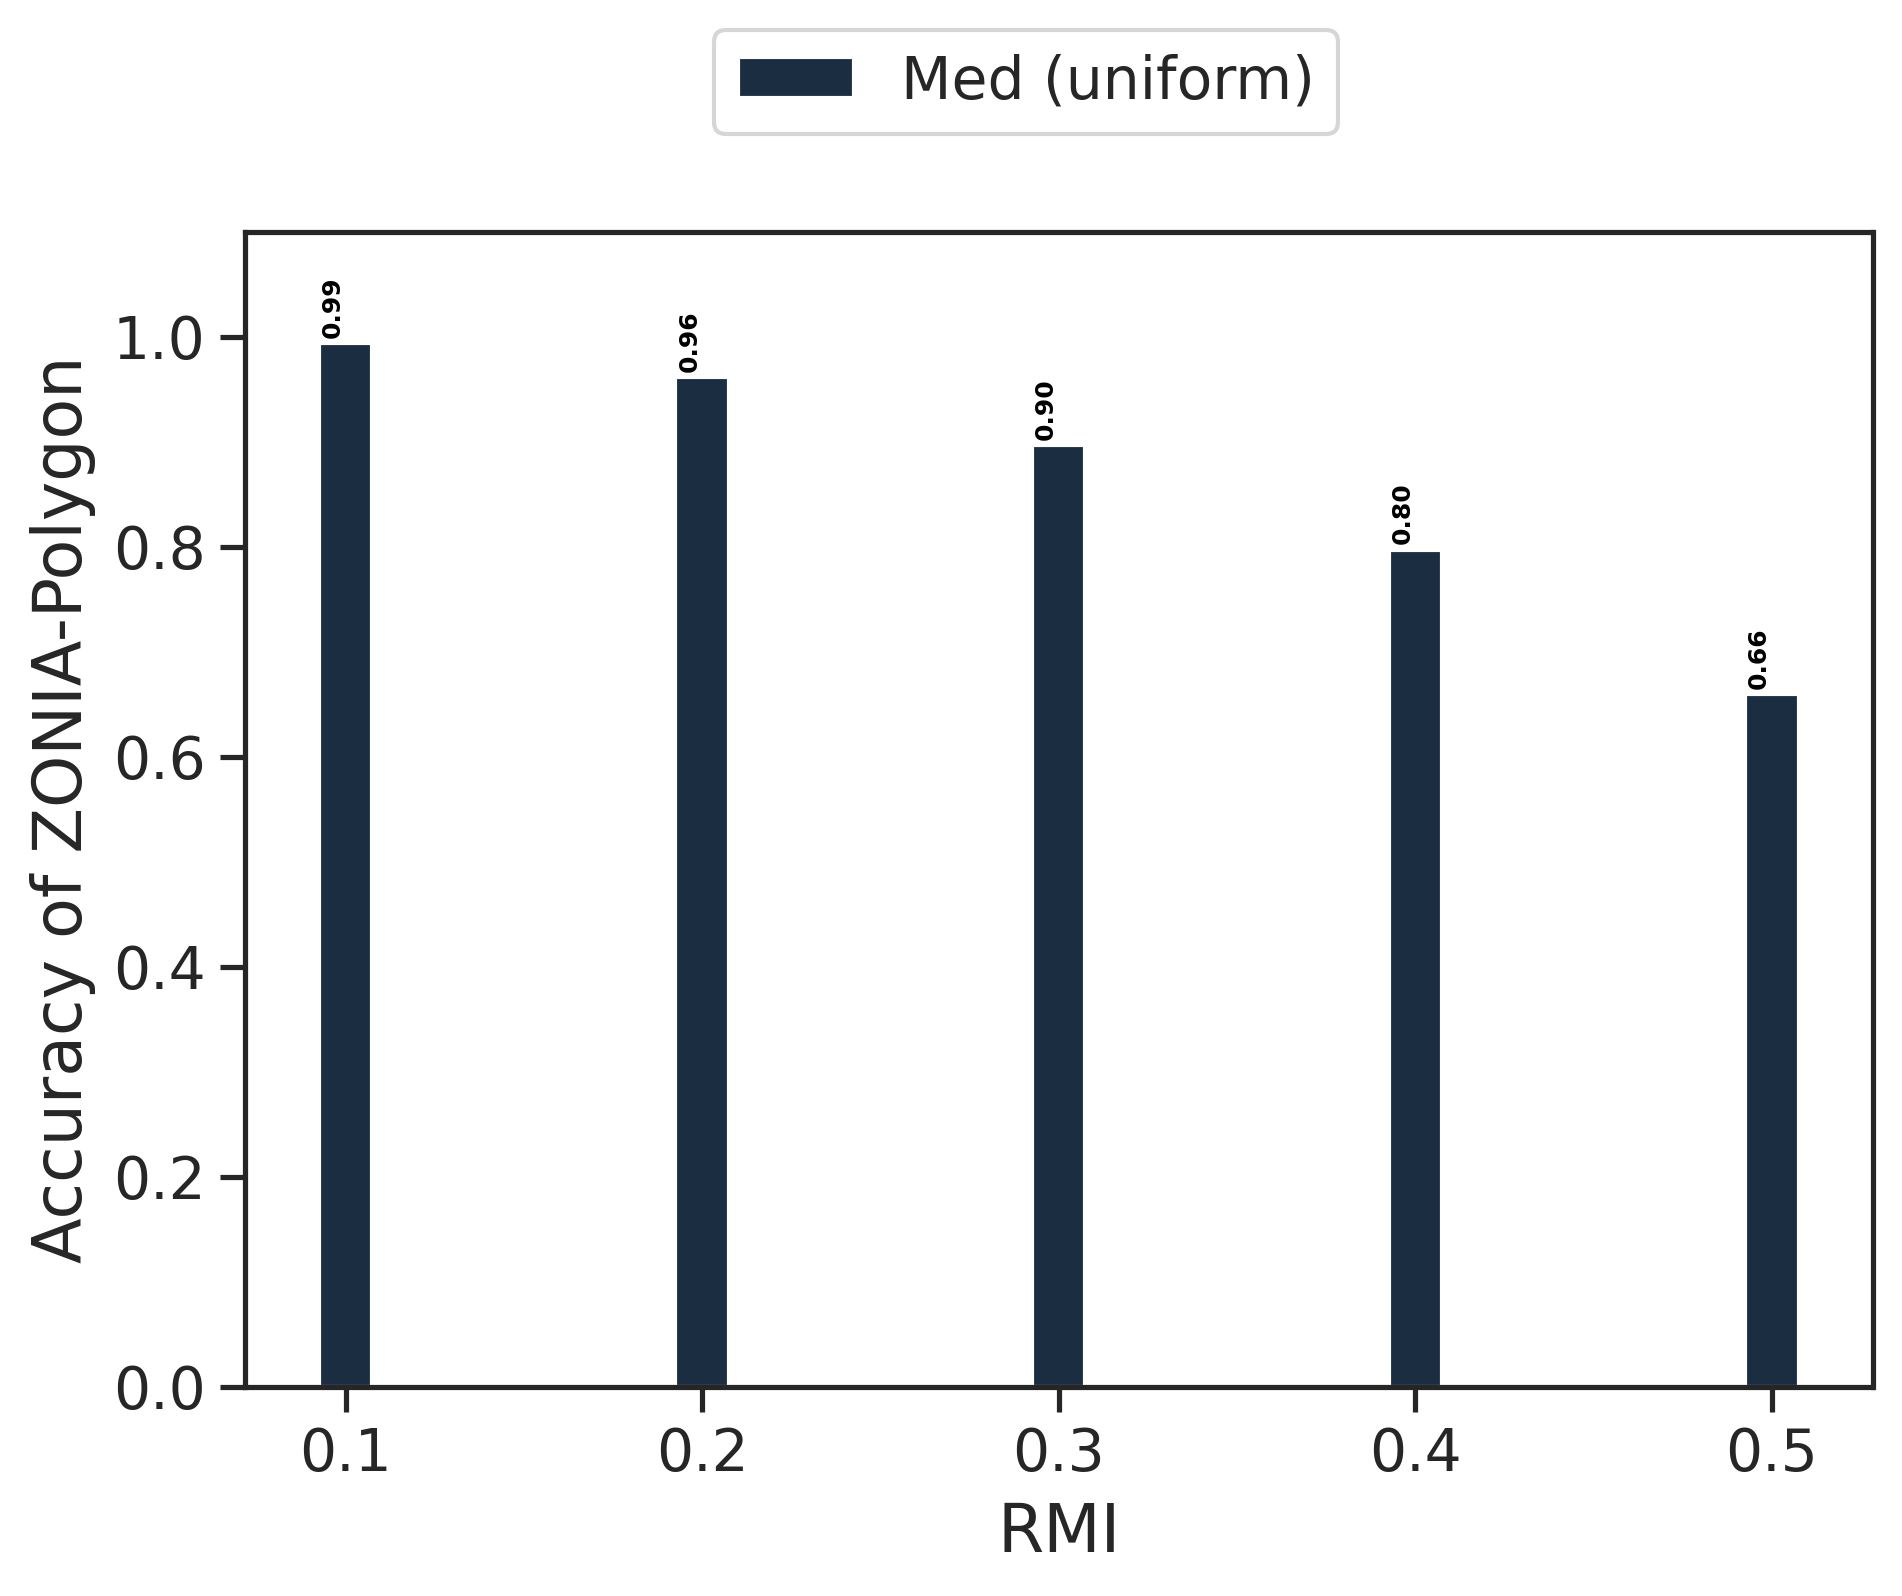

In [14]:
df_tail = df.drop(df[(df['time'] < 3600)].index) # take only the tail of the simulation


zonia_barplot("ideal_accuracy_tail.png", df_tail[df_tail['fav_chain'] == -1.0], chain_name="ZONIA-Ideal")
zonia_barplot("zoniamc_accuracy_tail.png", df_tail[df_tail['fav_chain'] == 0.0])
zonia_barplot("ethereum_accuracy_tail.png", df_tail[df_tail['fav_chain'] == 1.0], chain_name="ZONIA-Ethereum")
zonia_barplot("avalanche_accuracy_tail.png", df_tail[df_tail['fav_chain'] == 2.0], chain_name="ZONIA-Avalanche")
zonia_barplot("polygon_accuracy_tail.png", df_tail[df_tail['fav_chain'] == 3.0], chain_name="ZONIA-Polygon")

/tmp/ipykernel_45614/385648419.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.barplot(data=df[df['fav_chain'] >= 0 ][df['cost_time_param'] == 0.0], x="fav_chain", y="actual_delay", palette=zonia_palette2)
/tmp/ipykernel_45614/385648419.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['fav_chain'] >= 0 ][df['cost_time_param'] == 0.0], x="fav_chain", y="actual_delay", palette=zonia_palette2)
/tmp/ipykernel_45614/385648419.py:3: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(data=df[df['fav_chain'] >= 0 ][df['cost_time_param'] == 0.0], x="fav_chain", y="actual_delay", palette=zonia_palette2)


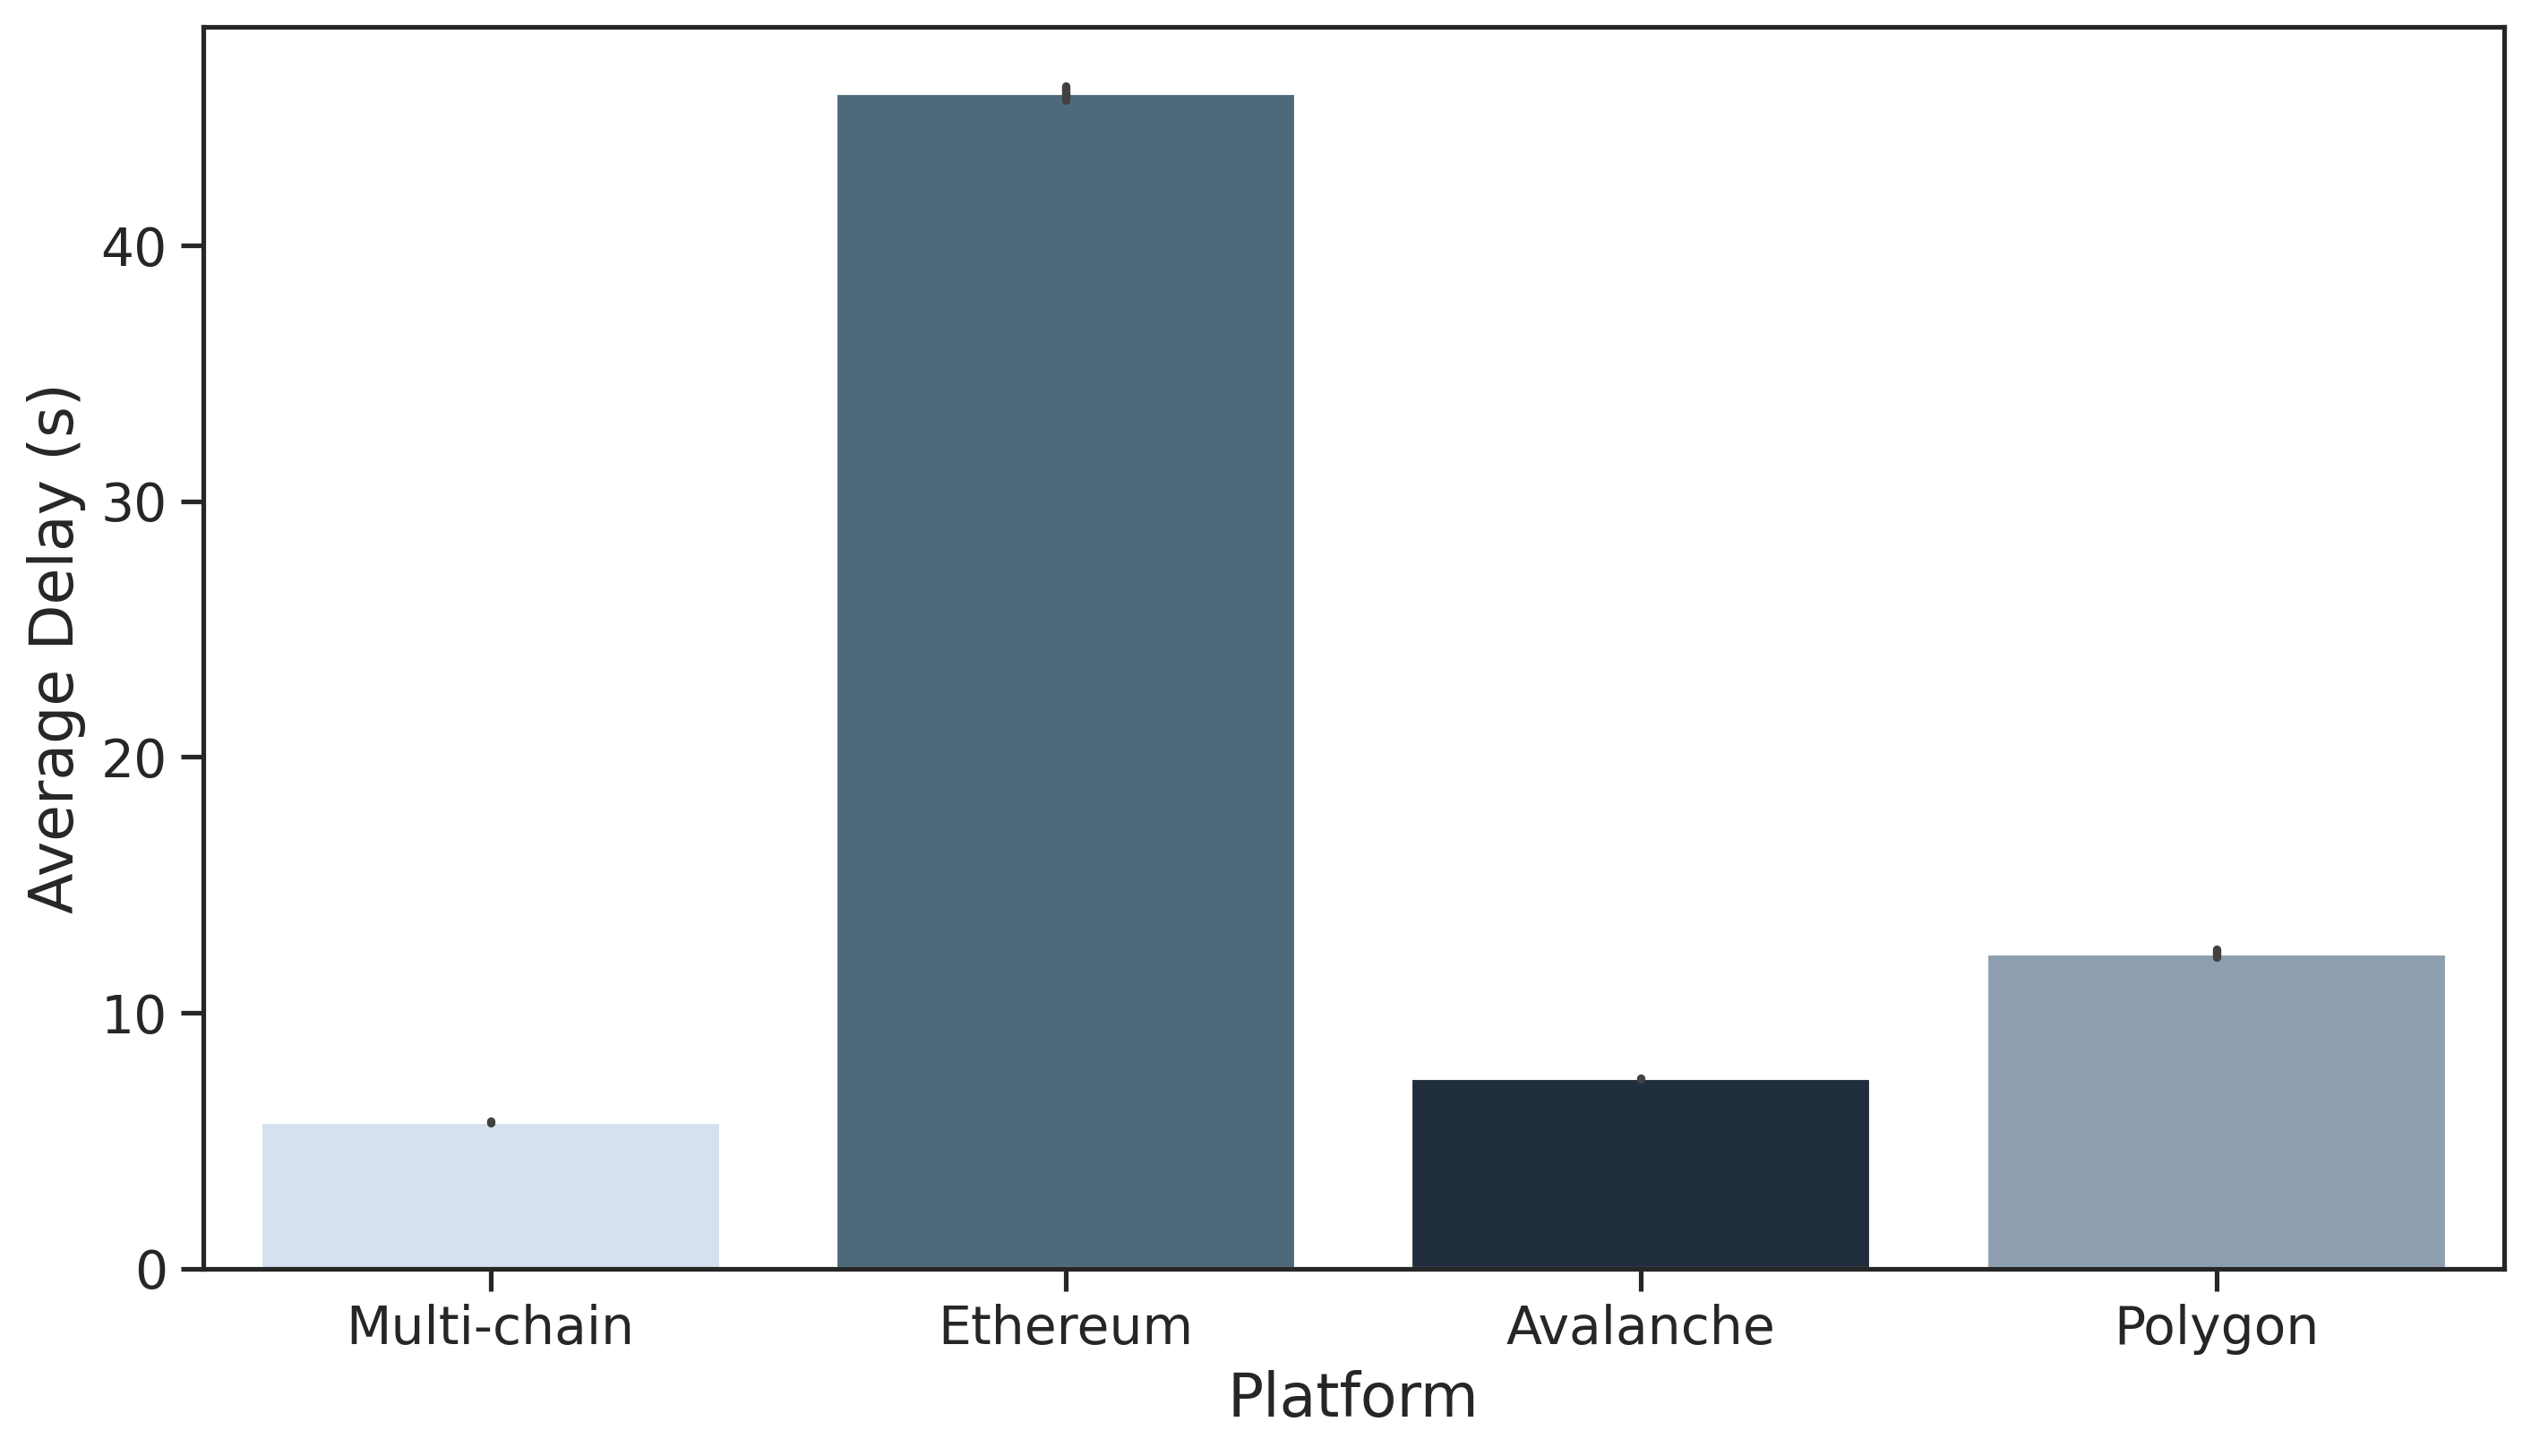

In [15]:

plt.figure(figsize=(10, 6))
hue_order = sorted(df['fav_chain'].unique())
sns.barplot(data=df[df['fav_chain'] >= 0 ][df['cost_time_param'] == 0.0], x="fav_chain", y="actual_delay", palette=zonia_palette2)
plt.xlabel("Platform")
plt.ylabel("Average Delay (s)")
xticks = [0, 1, 2, 3]
xticklabels = ["Multi-chain", "Ethereum", "Avalanche", "Polygon"]
plt.xticks(xticks, xticklabels)
#plt.title("Request-response delay (ZONIA-MC optimized for delay)")
plt.tight_layout()
plt.savefig("delay_by_chain.png", dpi=300)
plt.show()

/tmp/ipykernel_45614/368879645.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.barplot(data=df[df['fav_chain'] >= 0 ][df['cost_time_param'] == 1.0], x="fav_chain", y="actual_cost", palette=zonia_palette2)
/tmp/ipykernel_45614/368879645.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['fav_chain'] >= 0 ][df['cost_time_param'] == 1.0], x="fav_chain", y="actual_cost", palette=zonia_palette2)
/tmp/ipykernel_45614/368879645.py:3: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(data=df[df['fav_chain'] >= 0 ][df['cost_time_param'] == 1.0], x="fav_chain", y="actual_cost", palette=zonia_palette2)


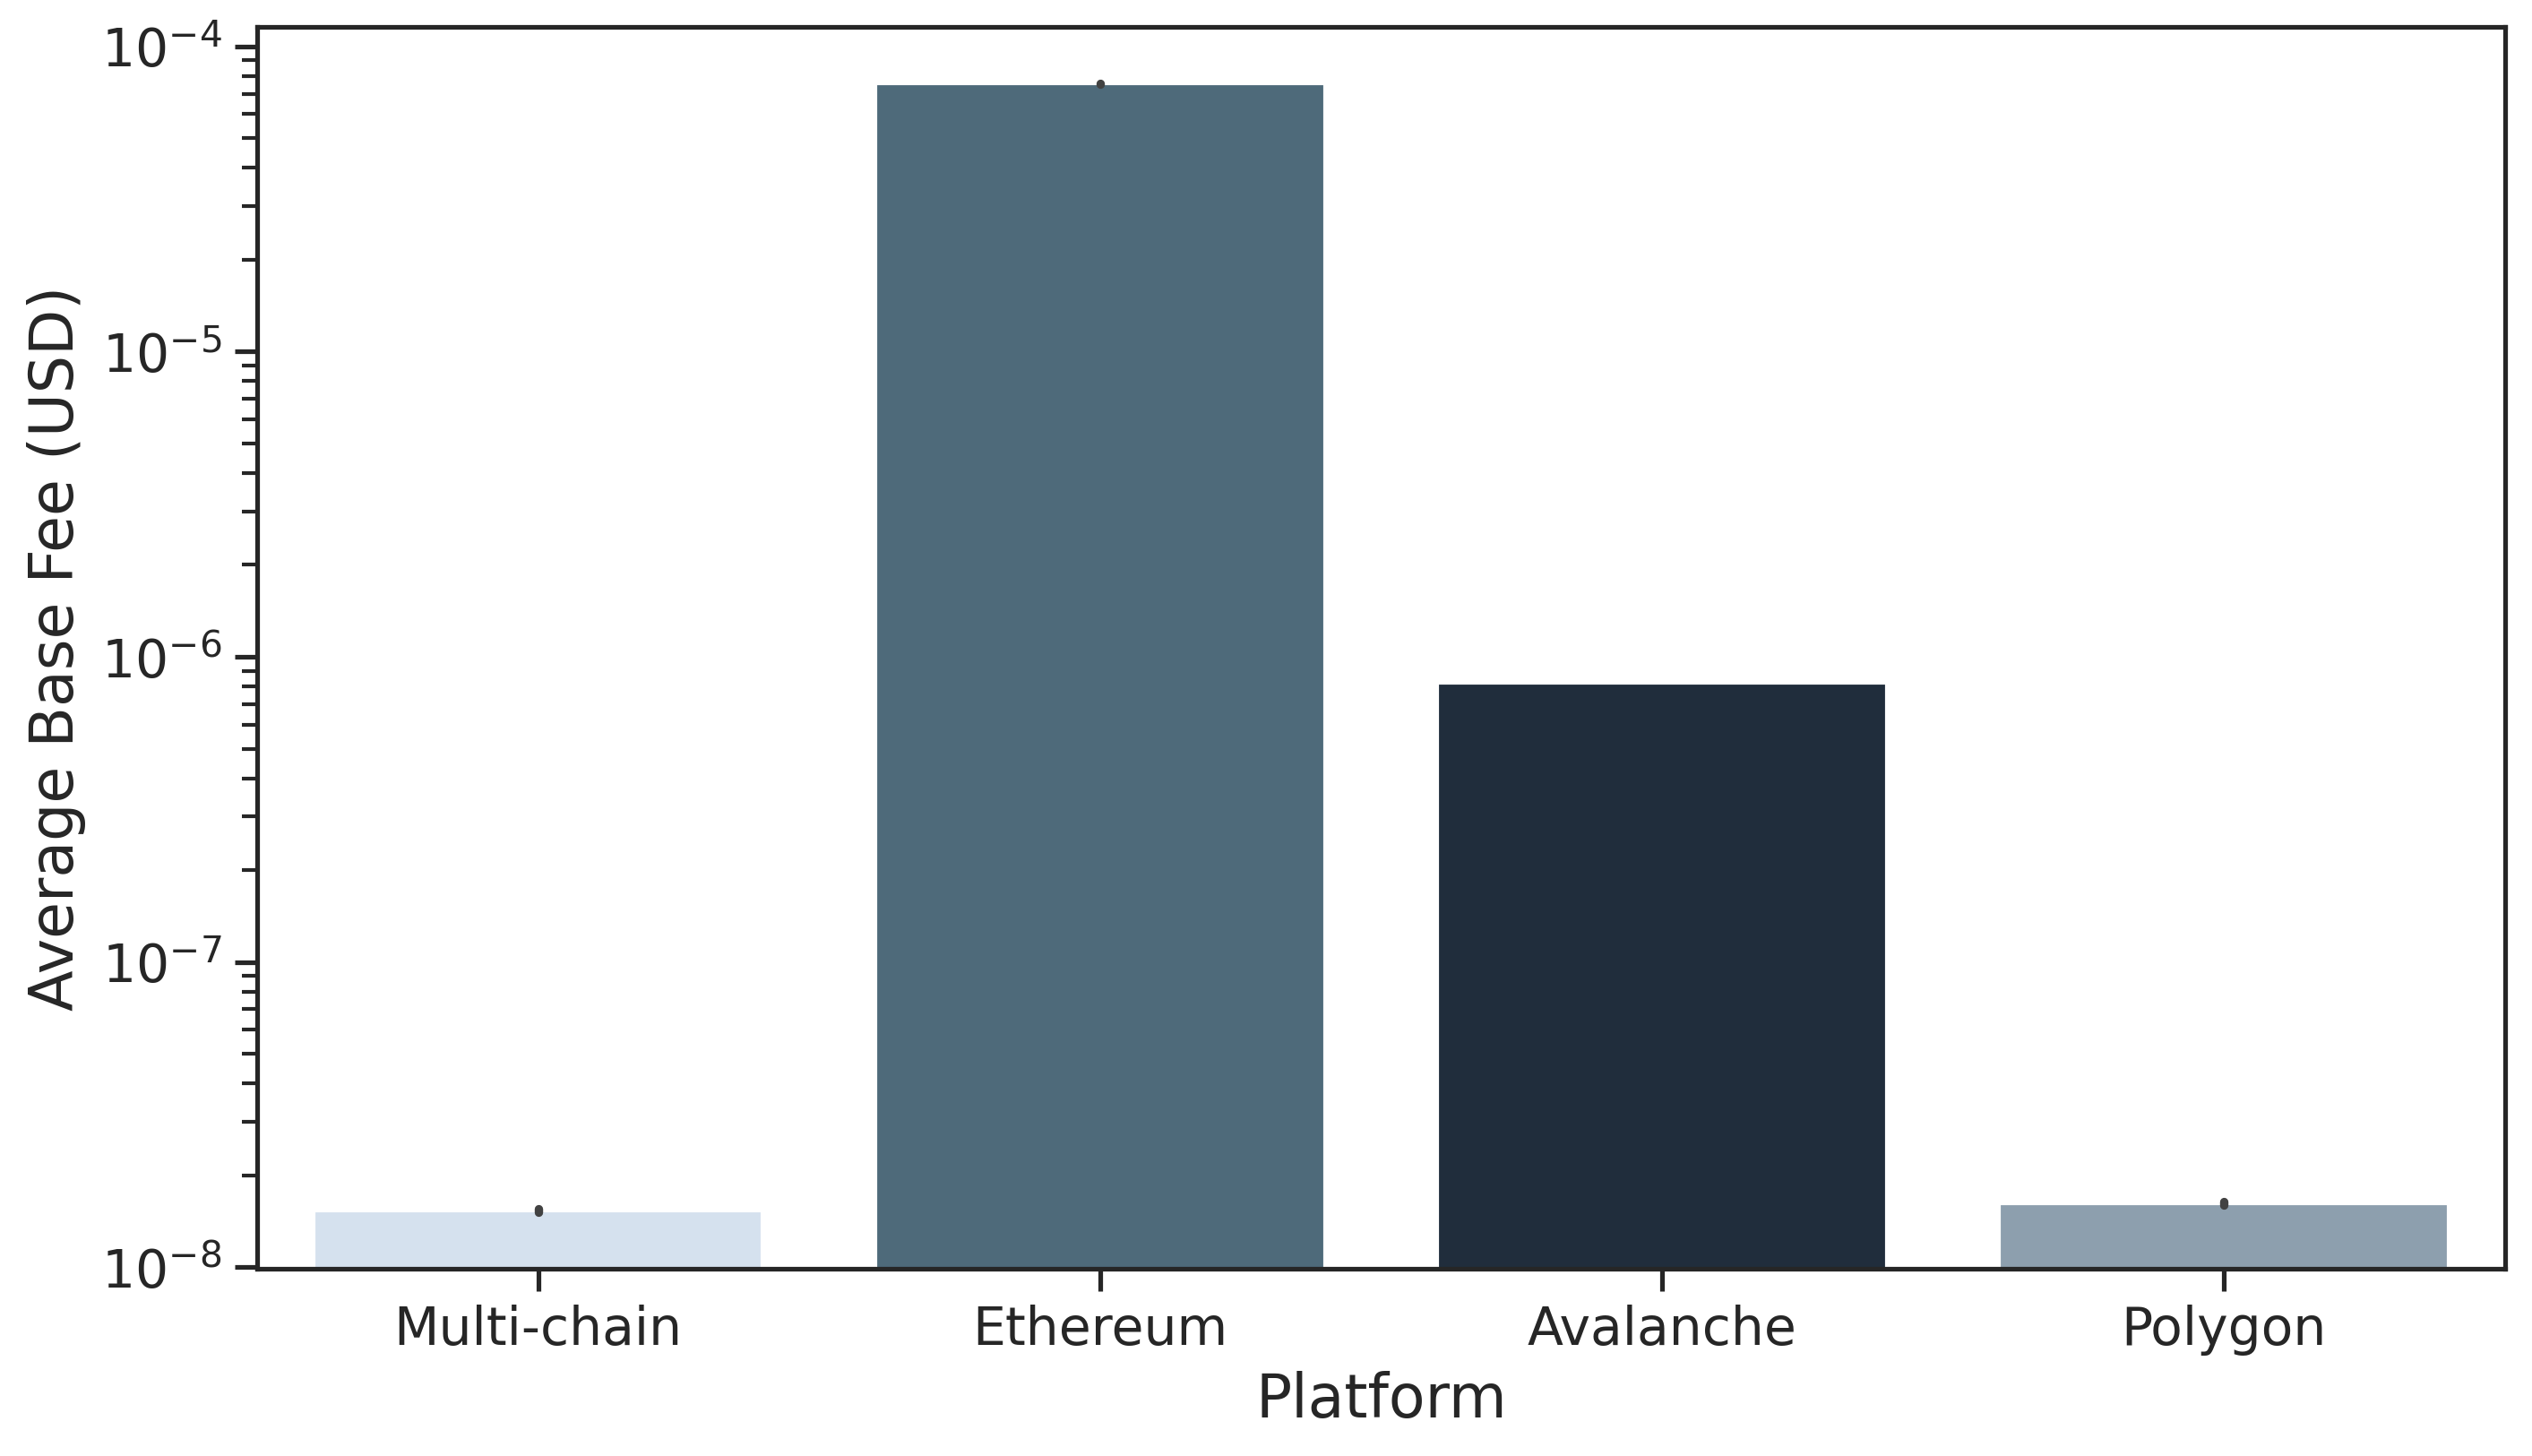

In [16]:
plt.figure(figsize=(10, 6))
hue_order = sorted(df['fav_chain'].unique())
sns.barplot(data=df[df['fav_chain'] >= 0 ][df['cost_time_param'] == 1.0], x="fav_chain", y="actual_cost", palette=zonia_palette2)
plt.xlabel("Platform")
plt.ylabel("Average Base Fee (USD)")
xticks = [0, 1, 2, 3]
xticklabels = ["Multi-chain", "Ethereum", "Avalanche", "Polygon"]
plt.xticks(xticks, xticklabels)
#plt.title("Base Fee price by Chain (ZONIA-MC optimized for price)")
plt.yscale('log')
plt.tight_layout()
plt.savefig("cost_by_chain.png", dpi=300)
plt.show()

/tmp/ipykernel_45614/3386044118.py:2: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df[df['fav_chain'] >= 0], x="cost_time_param", y="Objective Percentage", hue="fav_chain", palette=zonia_palette2, linewidth=2.5, marker="o")


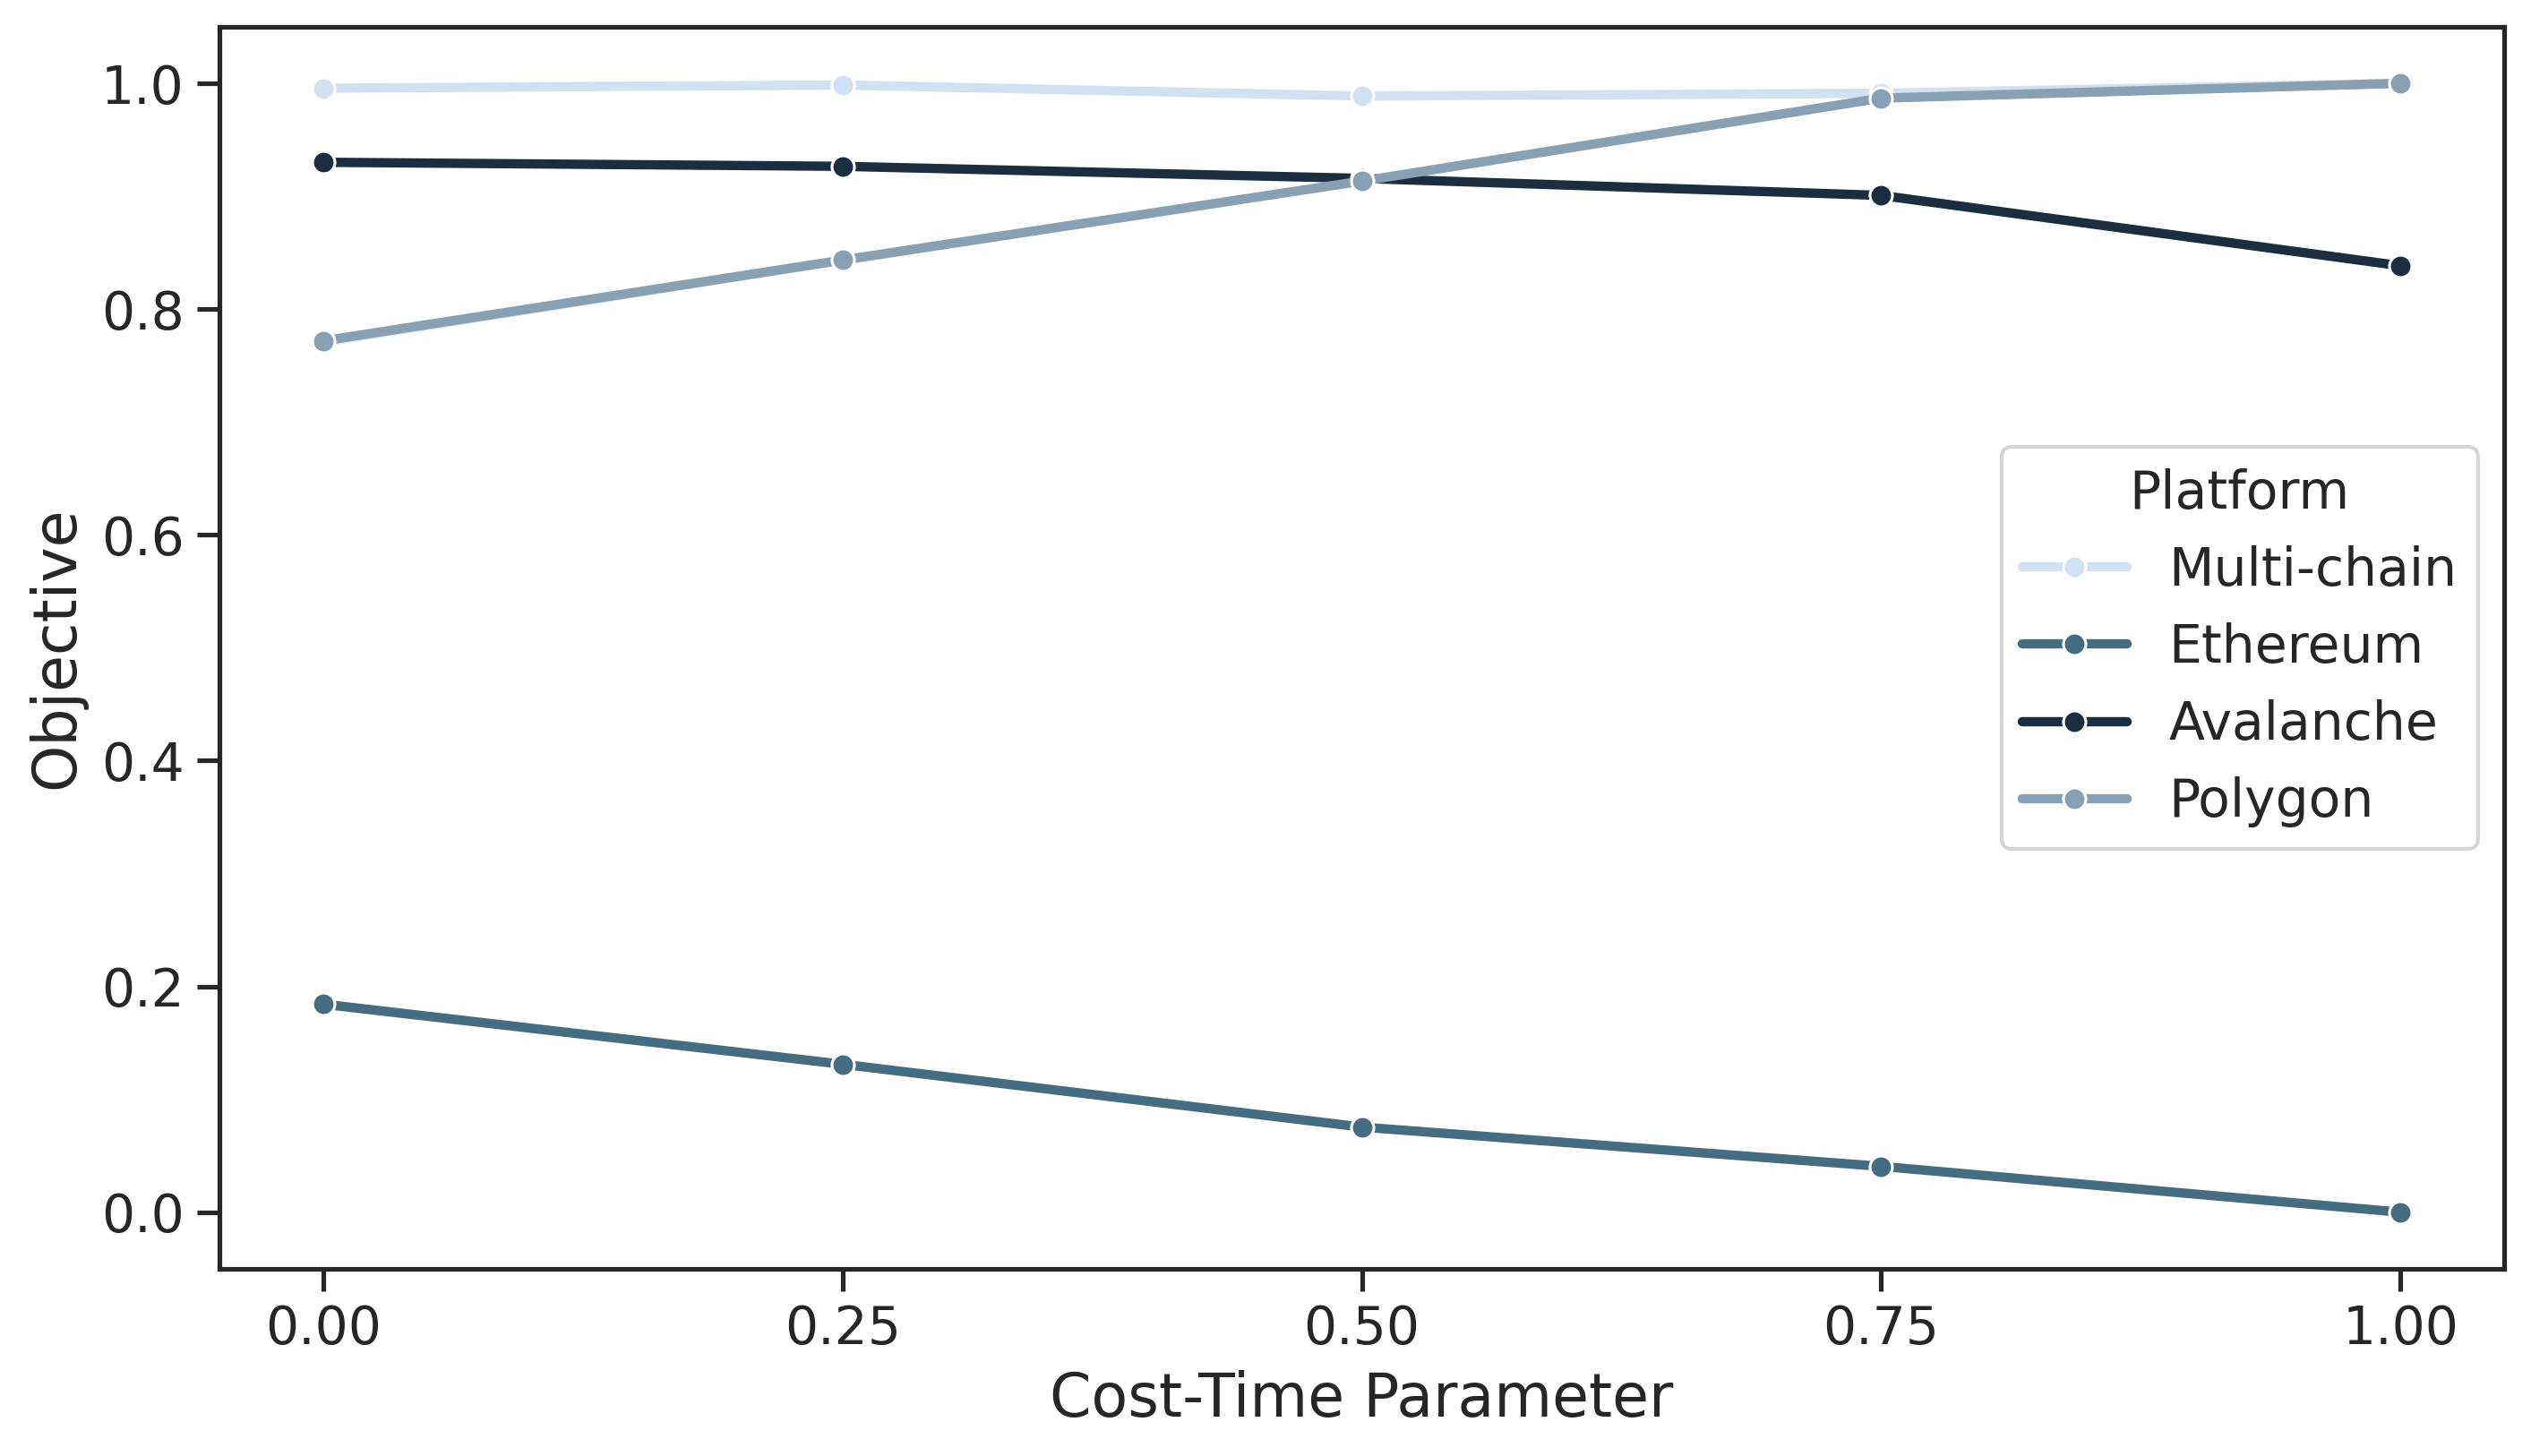

In [17]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=df[df['fav_chain'] >= 0], x="cost_time_param", y="Objective Percentage", hue="fav_chain", palette=zonia_palette2, linewidth=2.5, marker="o")
legendlabels = ["Multi-chain", "Ethereum", "Avalanche", "Polygon"]
sns.move_legend(ax, 'best', labels=legendlabels, title="Platform")
plt.xlabel("Cost-Time Parameter")
plt.ylabel("Objective")
# set xticks as in the cost_time_param values
plt.xticks(ticks=sorted(df['cost_time_param'].unique()))
#plt.title("Objective Percentage over the optimum by Cost-Time Parameter")
plt.tight_layout()
plt.savefig("objective_percentage_by_cost_time_param.png", dpi=300)
plt.show()